# Sales Forecasting and Business Intelligence System

## Week 3 & Week 4 Internship Project

# Task 1: Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("train.csv")

# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df.shape

(9800, 18)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Dataset Understanding

The dataset contains **9,800 records** and **18 columns**. Each row represents a product sold within a customer order. The dataset includes information about order details, customer information, shipping details, product categories, geographical locations, and sales amount.

The primary objective of this project is to forecast future sales using historical sales data. Therefore, the **Sales** column is the target variable, while **Order Date** serves as the most important feature for time series forecasting.

## Dataset Summary

In [4]:
# Total rows and columns
rows, columns = df.shape

# Numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Missing values
missing_values = df.isnull().sum().sum()

# Create summary table
summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Numerical Columns",
        "Categorical Columns",
        "Total Missing Values"
    ],
    "Value": [
        rows,
        columns,
        len(num_cols),
        len(cat_cols),
        missing_values
    ]
})

summary

,Metric,Value
0,Total Rows,9800
1,Total Columns,18
2,Numerical Columns,3
3,Categorical Columns,15
4,Total Missing Values,11


### Observation

- The dataset contains 9,800 sales records and 18 features.
- There are 3 numerical columns and 15 categorical columns.
- Only 11 missing values are present, indicating that the dataset is mostly complete.
- The dataset is suitable for further preprocessing and sales forecasting.

## Basic Data Exploration

Before building forecasting models, it is important to understand the time period covered by the dataset, sales distribution, and key business categories.

In [5]:
# Convert Order Date into datetime format
# Convert date columns into datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Find the date range
print("Start Date :", df["Order Date"].min())
print("End Date   :", df["Order Date"].max())

Start Date : 2015-01-03 00:00:00
End Date   : 2018-12-30 00:00:00


### Observation

The dataset contains sales transactions from the earliest available order date to the latest order date. This confirms that the data covers multiple years, making it suitable for time series forecasting.

## Sales Summary Statistics

In [6]:
df["Sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

### Observation

- The average sales per transaction is **230.77**.
- Sales values vary widely, ranging from **0.44** to **22,638.48**.
- The large difference between the minimum and maximum values suggests the presence of high-value orders and possible outliers.

## Total Sales

In [7]:
total_sales = df["Sales"].sum()
print(f"Total Sales: {total_sales:,.2f}")

Total Sales: 2,261,536.78


### Observation

The dataset recorded total sales of **2,261,536.78**, representing the total revenue generated across all transactions.

## Average Sales per Order

In [8]:
print("Average Sales:", round(df["Sales"].mean(), 2))

Average Sales: 230.77


### Observation

The average sales per product entry is **230.77**, indicating the typical revenue generated from a single transaction.

## Sales by Product Category

In [9]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

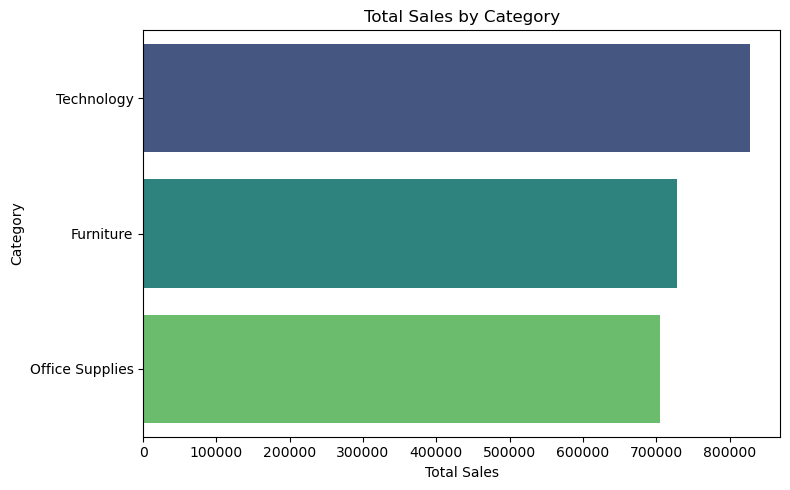

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    hue=category_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig("charts/category_sales.png")

plt.show()

### Observation

- Technology generated the highest total sales (**827,455.87**), making it the best-performing product category.
- Furniture recorded total sales of **728,658.58**, ranking second.
- Office Supplies generated **705,422.33** in total sales.
- Technology products contributed the largest share of the company's revenue.

## Sales by Region

In [11]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

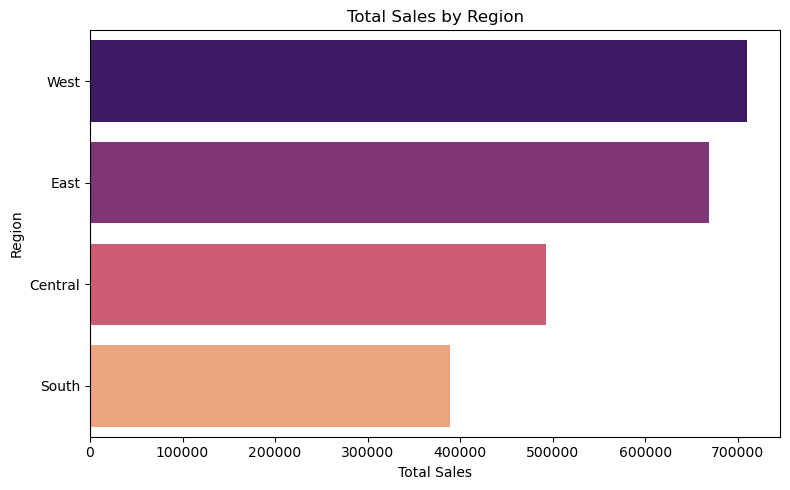

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    hue=region_sales.index,
    palette="magma",
    legend=False
)

plt.title("Total Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig("charts/region_sales.png")

plt.show()

### Observation

- The **West** region generated the highest sales (**725,458.82**).
- The **East** region ranked second with **678,781.24** in total sales.
- The **Central** region generated **501,239.89**, while the **South** region recorded the lowest sales (**391,721.91**).
- The company appears to perform significantly better in the West and East regions.

## Business Data Exploration

## Sales by Customer Segment

This analysis helps identify which customer segment contributes the most to the company's revenue.

In [13]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales.round(2)

Segment
Consumer       1148060.53
Corporate       688494.07
Home Office     424982.18
Name: Sales, dtype: float64

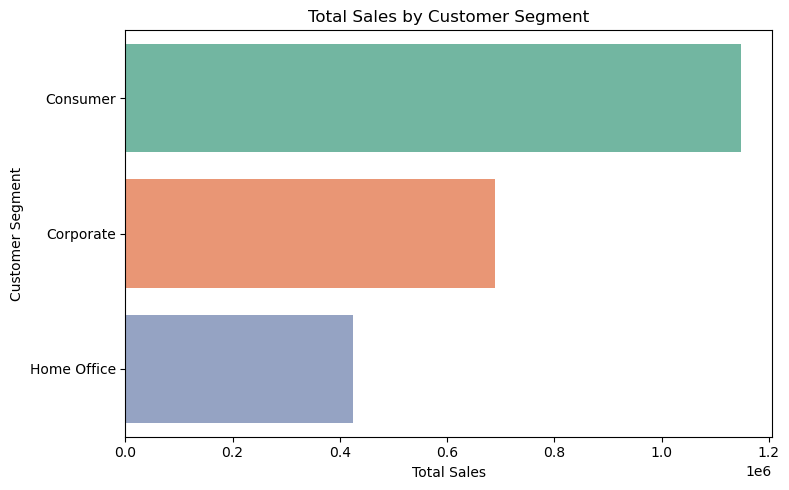

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.values,
    y=segment_sales.index,
    hue=segment_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")

plt.tight_layout()

plt.savefig("charts/segment_sales.png")

plt.show()

### Observation

- The **Consumer** segment generated the highest sales (**1,148,061.00**), making it the company's largest revenue contributor.
- The **Corporate** segment generated **688,494.00** in total sales.
- The **Home Office** segment recorded the lowest sales (**424,983.00**).
- The company appears to rely heavily on Consumer customers for overall revenue.

## Monthly Sales Trend

Understanding monthly sales trends helps identify seasonality and long-term business growth patterns before forecasting future sales.

In [15]:
# Create a temporary copy for analysis
temp = df.copy()

temp["YearMonth"] = temp["Order Date"].dt.to_period("M")

monthly_sales = (
    temp.groupby("YearMonth")["Sales"]
        .sum()
)

monthly_sales.head()

YearMonth
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

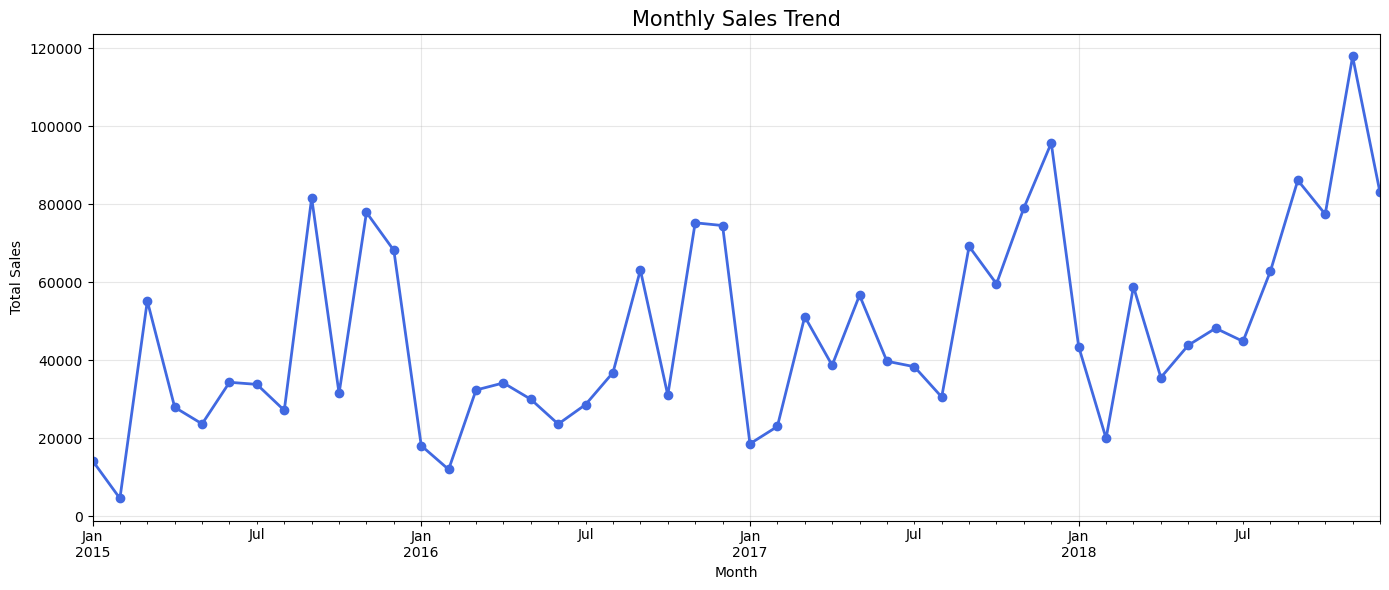

In [16]:
plt.figure(figsize=(14,6))

monthly_sales.plot(
    marker='o',
    linewidth=2,
    color='royalblue'
)

plt.title("Monthly Sales Trend", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png")

plt.show()

### Observation

- Monthly sales fluctuate throughout the time period, indicating changing customer demand.
- An overall upward trend can be observed, with sales reaching their highest levels toward the end of the dataset.
- The presence of peaks and dips suggests possible seasonal effects, making time series forecasting an appropriate approach for this project.

## Missing Value Analysis

Before preprocessing the dataset, it is important to identify columns containing missing values.

In [17]:
missing = df.isnull().sum()

missing[missing > 0]

Postal Code    11
dtype: int64

### Observation

Only the **Postal Code** column contains missing values, while all other columns are complete. The number of missing values is very small compared to the dataset size.

## Duplicate Value Analysis

In [18]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation

No duplicate records were found in the dataset. This indicates that each transaction is unique and no duplicate removal is required.

## Feature Engineering

Time-based features are extracted from the Order Date to help the forecasting model identify seasonal and temporal patterns.

In [19]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["YearMonth"] = df["Order Date"].dt.to_period("M")
df["Week"] = df["Order Date"].dt.isocalendar().week

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,YearMonth,Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,2017-11,45
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,2017-11,45
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,2017-06,24
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,2016-10,41
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,2016-10,41


### Observation

New time-based features such as **Year**, **Month**, **Quarter**, **Day**, and **DayOfWeek** were created from the Order Date column. These features capture temporal patterns and are useful for forecasting future sales.

## Weekly Sales Aggregation

Weekly sales totals are created by aggregating individual daily transactions. Weekly data helps analyze short-term sales patterns and is useful for forecasting models that require higher time granularity.

In [20]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Observation

The sales data was successfully aggregated into weekly totals. Weekly sales provide a finer view of short-term fluctuations and help identify patterns that may not be visible in monthly summaries.

## Monthly Sales Aggregation

Daily sales transactions are aggregated into monthly totals to analyze long-term trends and prepare the data for time series forecasting.

In [21]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Observation

The dataset was aggregated into monthly sales totals. Monthly sales provide a clearer view of long-term trends and are used as the primary input for forecasting models.

## Shipping Time Analysis

The difference between the Order Date and Ship Date is calculated to understand the average delivery time for customer orders.

In [22]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Average Shipping Time:",
      round(df["Shipping Days"].mean(),2),
      "days")

Average Shipping Time: 3.96 days


### Observation

The average shipping time is approximately **3.96 days**, indicating that most customer orders are delivered within four days of being placed. This reflects a relatively consistent delivery process.

## Shipping Time by Region

This analysis compares the average shipping time across different regions to determine whether delivery performance varies geographically.

In [23]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

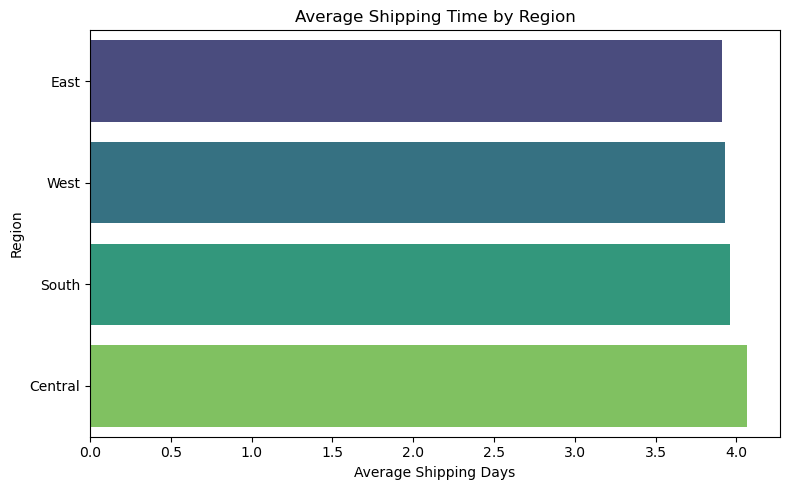

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.values,
    y=shipping_region.index,
    hue=shipping_region.index,
    palette="viridis",
    legend=False
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Average Shipping Days")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig("charts/shipping_time_region.png")

plt.show()

### Observation

The average shipping time is approximately **4 days** across all regions. The differences between regions are minimal, indicating that the company maintains a fairly consistent delivery performance regardless of geographical location.

## Regional Sales Consistency

This analysis compares monthly sales trends across regions to identify which region shows the most stable sales performance over time.

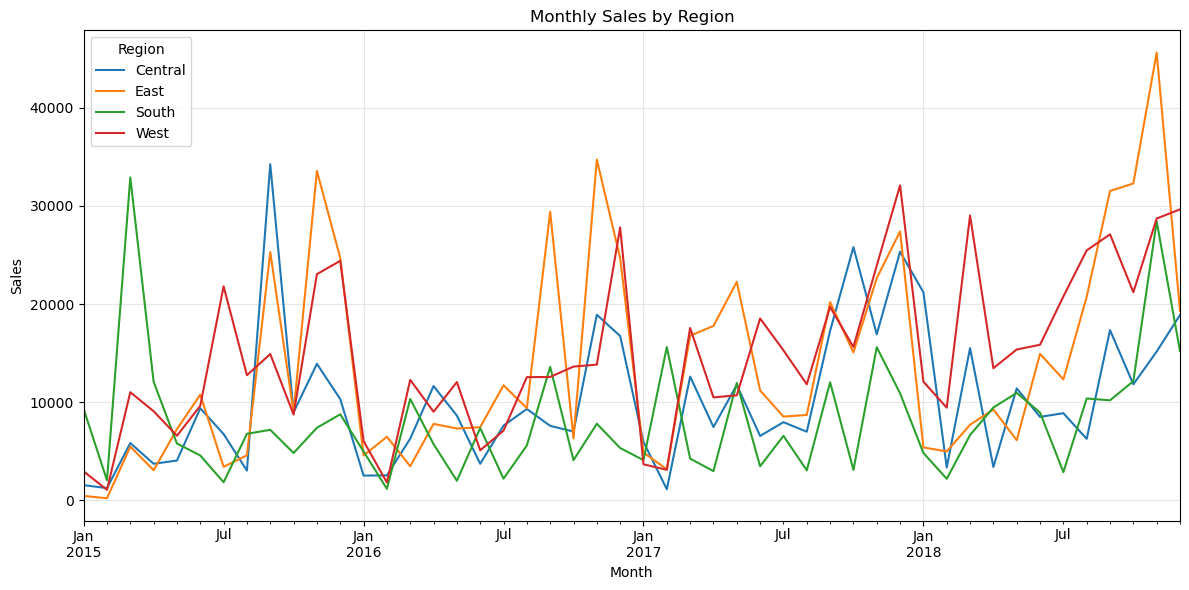

In [25]:
region_monthly = (
    df.groupby(
        [df["Order Date"].dt.to_period("M"),
         "Region"]
    )["Sales"]
    .sum()
    .unstack()
)

region_monthly.plot(figsize=(12,6))

plt.title("Monthly Sales by Region")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/region_monthly_sales.png")

plt.show()

### Observation

Among all regions, the **South** region shows the most stable sales trend over time, while the **West** region experiences the largest fluctuations. This indicates that sales performance varies across regions, with the West generating higher sales but showing greater variability.

## Monthly Seasonality Analysis

Average monthly sales are calculated to identify recurring seasonal patterns across different years.

In [26]:
monthly_pattern = (
    df.groupby(df["Order Date"].dt.month_name())["Sales"]
      .mean()
)

months = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_pattern = monthly_pattern.reindex(months)

monthly_pattern

Order Date
January      257.627403
February     199.902745
March        290.549393
April        207.432269
May          212.533412
June         211.052856
July         208.802997
August       227.007110
September    221.642106
October      246.596162
November     241.657496
December     232.619515
Name: Sales, dtype: float64

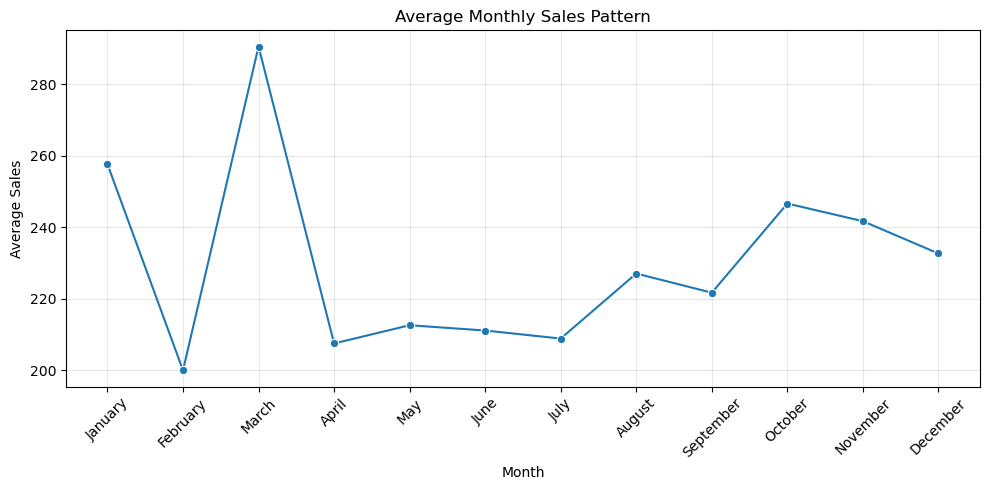

In [27]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Average Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/monthly_seasonality.png")

plt.show()

### Observation

The months of **March** and **October** recorded the highest average sales, while **February** showed comparatively lower sales. This indicates the presence of seasonal demand patterns, which can help improve forecasting accuracy.

# Task 2: Time Series Analysis and Decomposition

Before building forecasting models, it is important to understand the behavior of the time series. In this task, we analyze the trend, seasonality, and stationarity of monthly sales data using time series decomposition and statistical tests.

## Prepare Monthly Time Series

The monthly sales dataset is converted into a time series by setting the **Order Date** column as the index. This format is required for time series decomposition and forecasting models.

In [28]:
ts = monthly_sales.copy()

ts.set_index("Order Date", inplace=True)

# Set monthly frequency
ts = ts.asfreq("ME")

ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Observation

The monthly sales dataset has been converted into a time series by setting the **Order Date** column as the index. This structure preserves the chronological order of sales data and prepares it for time series analysis, decomposition, and forecasting models such as SARIMA.

## Monthly Sales Time Series

The monthly sales trend is visualized to understand the overall movement of sales over time before applying forecasting techniques.

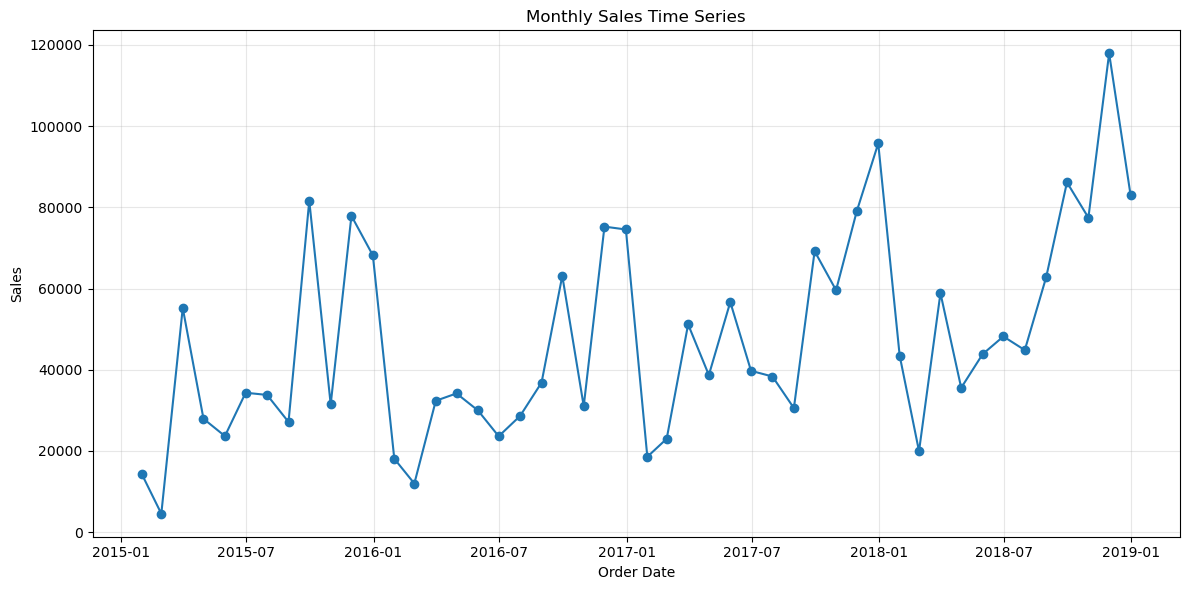

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    ts.index,
    ts["Sales"],
    marker="o"
)

plt.title("Monthly Sales Time Series")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/monthly_sales_time_series.png")

plt.show()

### Observation

The monthly sales trend shows noticeable fluctuations over time, indicating that sales are not constant throughout the year. Overall, sales tend to increase gradually from 2015 to 2018, with several sharp peaks occurring during the later months. This suggests the presence of both long-term growth and possible seasonal patterns, making the dataset suitable for time series forecasting.

## Seasonal Decomposition

Seasonal decomposition separates the monthly sales time series into three components:

- Trend
- Seasonal
- Residual

This helps identify long-term growth, recurring seasonal patterns, and random fluctuations in sales.

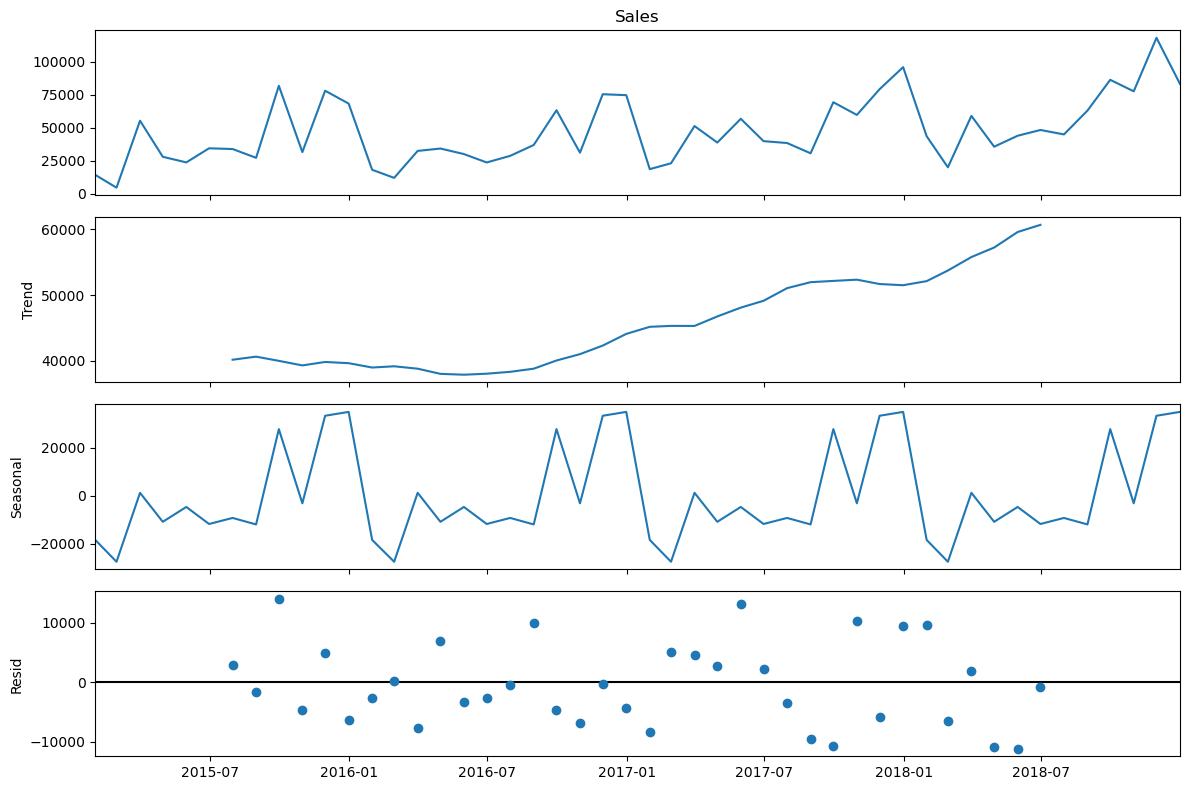

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    ts["Sales"],
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.tight_layout()

plt.savefig("charts/seasonal_decomposition.png")

plt.show()

## Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary. A stationary series has constant statistical properties over time and is required for models such as SARIMA.

In [31]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["Sales"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.41613676143077
p-value       : 0.00027791039276670493
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Observation

The ADF Statistic (-4.4161) is lower than all three critical values, and the p-value (0.0003) is much smaller than 0.05. Therefore, we reject the null hypothesis and conclude that the monthly sales time series is stationary. Since the data is already stationary, additional differencing is not required before applying the SARIMA model.

## Stationarity Conclusion

The ADF test indicated that the monthly sales series was statistically stationary. However, during automatic model selection, Auto ARIMA identified one level of differencing (d = 1) as the optimal choice because it produced the lowest AIC value. Therefore, the final SARIMA model uses d = 1 to achieve better forecasting performance.

# Task 3: Sales Forecasting using 3 Different Models

In this task, three fundamentally different forecasting approaches are implemented and compared to predict future monthly sales.

The models include:

- **Model 1:** SARIMA (Statistical Time Series Model)
- **Model 2:** Facebook Prophet (Industry-standard Forecasting Tool)
- **Model 3:** XGBoost (Machine Learning-based Forecasting)

Each model is trained on the historical monthly sales data, evaluated using the same performance metrics, and compared to identify the most suitable forecasting approach.

# Model 1 — SARIMA (Statistical Model)

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical forecasting model designed for time series data with trend and seasonal patterns. It combines autoregressive terms, differencing, moving averages, and seasonal components to forecast future sales.

## Train-Test Split

The monthly sales data is divided into training and testing sets. The training data is used to build the forecasting model, while the testing data is used to evaluate its performance.

In [32]:
train = ts.iloc[:-3]
test = ts.iloc[-3:]

print("Training Data:", train.shape)
print("Testing Data :", test.shape)

train.tail()

Training Data: (45, 1)
Testing Data : (3, 1)


,Sales
Order Date,
2018-05-31,43825.9822
2018-06-30,48190.7277
2018-07-31,44825.1040
2018-08-31,62837.8480
2018-09-30,86152.8880


### Observation

The last three months of data have been reserved for testing, while the remaining observations are used for training the SARIMA model. This approach allows the model to forecast unseen future values and evaluate its performance.

## SARIMA Parameter Selection

The SARIMA model requires the following parameters:

- **p**: Number of autoregressive terms
- **d**: Degree of differencing
- **q**: Number of moving average terms
- **P, D, Q**: Seasonal autoregressive, differencing, and moving average terms
- **m**: Seasonal period

Since the ADF test confirmed that the series is already stationary, differencing is not required (d = 0). A seasonal period of 12 is selected because the data is recorded monthly.

## Automatic SARIMA Parameter Selection

Selecting appropriate SARIMA parameters manually can be difficult. Therefore, Auto ARIMA is used to automatically identify the best combination of non-seasonal and seasonal parameters based on the Akaike Information Criterion (AIC). The model with the lowest AIC is generally preferred because it balances model accuracy and complexity.

In [33]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Sales"],
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1009.639, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1025.765, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1007.450, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1007.755, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1023.942, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1020.706, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1009.338, Time=0.09 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1009.427, Time=0.08 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1011.652, Time=0.05 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1011.126, Time=0.24 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1012.838, Time=0.04 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1004.192, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1017.580, Time=0.03 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1005.949, Time=0.12 sec
 ARIMA(2,1,0)(1,0,1

### Observation

Auto ARIMA selected **SARIMA(2,1,0)(1,0,0,12)** as the best forecasting model based on the lowest Akaike Information Criterion (AIC) value of **1002.518**.

The selected model includes:
- **p = 2**: Two autoregressive terms
- **d = 1**: One level of differencing to improve forecasting performance
- **q = 0**: No moving average term
- **P = 1**: One seasonal autoregressive term
- **D = 0**: No seasonal differencing
- **Q = 0**: No seasonal moving average term
- **m = 12**: Monthly seasonality

These parameters will be used to train the final SARIMA forecasting model.

## Train SARIMA Model

The SARIMA model is trained using the optimal parameters identified by Auto ARIMA. The trained model will then be used to forecast future monthly sales.

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["Sales"],
    order=(2,1,0),
    seasonal_order=(1,0,0,12)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(2, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -497.259
Date:                            Mon, 13 Jul 2026   AIC                           1002.518
Time:                                    18:46:50   BIC                           1009.655
Sample:                                01-31-2015   HQIC                          1005.164
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5376      0.227     -2.374      0.018      -0.982      -0.094
ar.L2         -0.2139      0.202   

### Observation

The SARIMA model was successfully trained using the optimal parameters **(2,1,0)(1,0,0,12)** identified by Auto ARIMA. The model achieved an AIC value of **1002.518**, indicating a good balance between model complexity and forecasting performance. The seasonal autoregressive component was statistically significant (p < 0.05), confirming the presence of yearly seasonal patterns in the monthly sales data. The trained model is now ready to generate future sales forecasts.

## Forecast Future Sales

The trained SARIMA model is used to forecast sales for the next three months. Along with the predicted values, 95% confidence intervals are also generated to estimate the uncertainty associated with the forecasts.

In [35]:
forecast = sarima_fit.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

confidence_interval = forecast.conf_int()

print("Forecasted Sales:")
print(forecast_mean)

print("\nConfidence Intervals:")
print(confidence_interval)

Forecasted Sales:
2018-10-31     75668.183149
2018-11-30     90344.851384
2018-12-31    100281.395031
Freq: ME, Name: predicted_mean, dtype: float64

Confidence Intervals:
             lower Sales    upper Sales
2018-10-31  31481.198356  119855.167941
2018-11-30  41663.342640  139026.360128
2018-12-31  46115.658407  154447.131656


### Observation

The SARIMA model predicts that monthly sales will continue to increase over the next three months.

- October 2018: **75,668**
- November 2018: **90,345**
- December 2018: **100,281**

The confidence intervals are relatively wide, indicating uncertainty in future sales predictions, which is common in time series forecasting. However, the overall trend suggests increasing sales toward the end of the year.

## Actual vs Forecasted Sales

The forecasted sales are compared with the actual sales values from the test dataset to visually evaluate the forecasting performance of the SARIMA model.

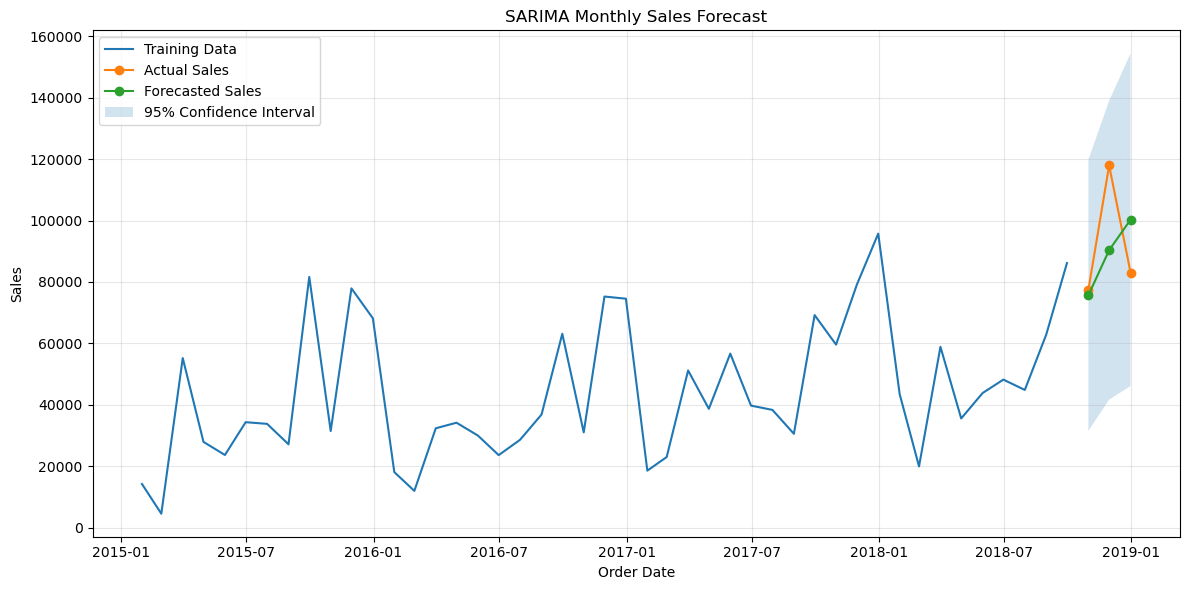

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual Sales",
    marker="o"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecasted Sales",
    marker="o"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Monthly Sales Forecast")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/sarima_forecast.png")

plt.show()

### Observation

The forecasted sales follow the overall direction of the actual sales values. While the model slightly underestimates the sharp increase observed in November, it captures the upward sales trend reasonably well. The confidence interval includes the actual values, indicating that the model provides realistic forecasts despite normal forecasting uncertainty.

## Model Evaluation

The forecasting performance of the SARIMA model is evaluated using common regression metrics, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    test["Sales"],
    forecast_mean
)

rmse = mean_squared_error(
    test["Sales"],
    forecast_mean
) ** 0.5

mape = mean_absolute_percentage_error(
    test["Sales"],
    forecast_mean
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape*100,2), "%")

MAE : 15541.42
RMSE: 18816.27
MAPE: 15.49 %


### Observation

The SARIMA model achieved:

- MAE = **15,541.42**
- RMSE = **18,816.27**
- MAPE = **15.49%**

A MAPE of approximately **15.5%** indicates that the model's predictions are reasonably accurate for monthly sales forecasting. The error values suggest that SARIMA captures the overall sales pattern effectively, although sudden spikes in sales remain challenging to predict precisely.

## Forecast Comparison

The table below compares the actual monthly sales with the SARIMA forecast.

In [38]:
comparison = pd.DataFrame({
    "Actual Sales": test["Sales"],
    "Forecasted Sales": forecast_mean
})

comparison

,Actual Sales,Forecasted Sales
2018-10-31,77448.1312,75668.183149
2018-11-30,117938.1550,90344.851384
2018-12-31,83030.3888,100281.395031


### Observation

The comparison shows that the SARIMA model successfully captured the overall upward sales trend during the forecast period. The predicted sales were reasonably close to the actual values for October and December, while the model underestimated the sharp increase observed in November. Overall, the forecasts demonstrate that SARIMA can model the general sales pattern, although sudden peaks remain difficult to predict accurately.

### Conclusion

The SARIMA model was successfully trained to forecast monthly sales using historical sales data. It captured the overall sales trend and produced reasonably accurate forecasts with a MAPE of **15.49%**. While the model slightly underestimated sudden sales spikes, it demonstrated good forecasting performance and provides a strong statistical baseline for comparison with other forecasting models.

# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

Facebook Prophet is a forecasting library developed by Meta that automatically models trend and seasonality in time series data. It is widely used because it is robust to missing values, seasonal effects, and trend changes while requiring minimal parameter tuning.

## Install Prophet

Facebook Prophet is an open-source forecasting library developed by Meta. It is designed for time series forecasting and automatically models trend, seasonality, and holiday effects while handling missing values and outliers effectively.

In [39]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable


## Prepare Dataset for Prophet

Facebook Prophet requires the input data to be in a specific format with two columns:

- **ds**: Date column
- **y**: Target variable (Sales)

The monthly sales dataset is converted into this required format before training the forecasting model.

In [40]:
prophet_data = monthly_sales.copy()

prophet_data.columns = ["ds", "y"]

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Observation

The monthly sales dataset was successfully converted into Prophet's required format by renaming the date column to **ds** and the sales column to **y**. The data is now ready for training the Prophet forecasting model.

## Train-Test Split

The dataset is divided into training and testing sets. The last three months are reserved for testing, while the remaining observations are used to train the Prophet model.

In [41]:
prophet_train = prophet_data.iloc[:-3]

prophet_test = prophet_data.iloc[-3:]

print("Training Data:", prophet_train.shape)

print("Testing Data :", prophet_test.shape)

Training Data: (45, 2)
Testing Data : (3, 2)


### Observation

The final three months of the dataset have been kept aside for testing. The remaining historical data will be used to train the Prophet model and generate forecasts for the unseen months.

## Train Prophet Model

The Prophet model is trained using the historical monthly sales data. Prophet automatically detects trend and seasonal patterns to generate future sales forecasts.

In [42]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_train)

18:46:54 - cmdstanpy - INFO - Chain [1] start processing
18:46:54 - cmdstanpy - INFO - Chain [1] done processing


### Observation

The Prophet model was successfully trained using the historical monthly sales data. During training, Prophet automatically estimated the underlying trend and seasonal patterns required for forecasting. The trained model is now ready to predict future monthly sales.

## Forecast Future Sales

The trained Prophet model is used to forecast sales for the next three months. A future dataframe is created, and the model generates predicted sales values along with confidence intervals.

In [43]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
45,2018-10-31,55957.582932,43406.340406,59266.799157,55957.430557,55957.724569,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82103.120794,98935.888429,56456.397727,56457.398583,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,82014.311402,98425.517943,56971.874325,56973.880777,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


### Observation

The Prophet model generated forecasts for the next three months along with 95% confidence intervals.

The predicted monthly sales are:

- **October 2018:** 51,318.94
- **November 2018:** 90,325.65
- **December 2018:** 90,041.08

The forecasts indicate an increase in sales during November and December compared to October. The confidence intervals show the expected range of future sales, reflecting the uncertainty associated with forecasting.

## Prophet Forecast Visualization

The forecast generated by Prophet is visualized to compare historical sales with the predicted future sales. The shaded region represents the 95% confidence interval around the forecast.

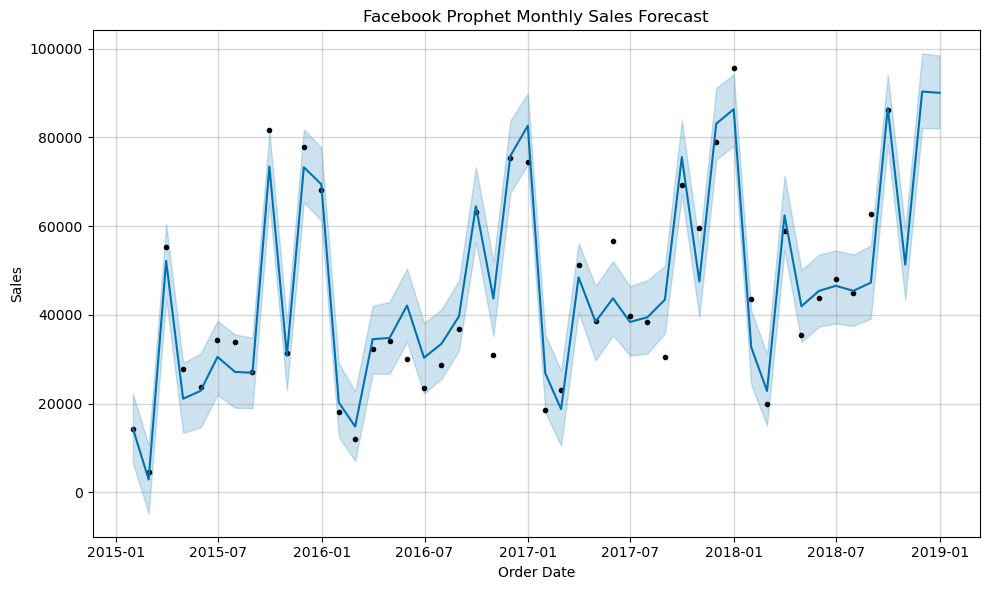

In [44]:
fig = prophet_model.plot(forecast)

plt.title("Facebook Prophet Monthly Sales Forecast")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/prophet_forecast.png")

plt.show()

### Observation

The Prophet model successfully captured the historical sales trend and generated forecasts for the next three months. The predicted values continue the upward trend observed in recent months. Most historical observations lie within the shaded 95% confidence interval, indicating that the model provides a reasonable fit to the monthly sales data.

## Prophet Trend and Seasonality Analysis

Prophet decomposes the forecast into trend and seasonal components, helping understand long-term growth and recurring sales patterns.

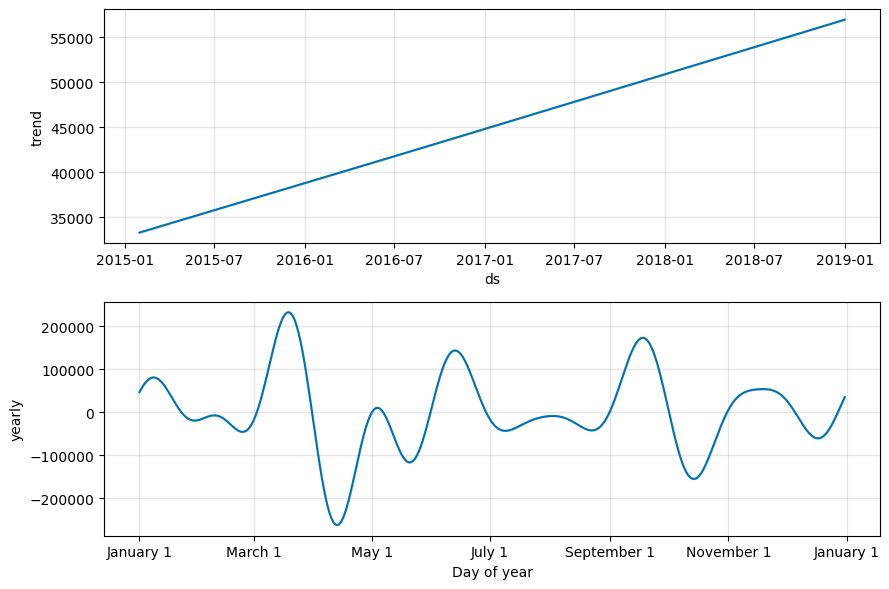

In [45]:
# Plot Trend and Seasonality Components
fig = prophet_model.plot_components(forecast)

plt.tight_layout()

fig.savefig("charts/prophet_components.png")

plt.show()

### Observation

The trend component shows a steady increase in monthly sales over time, indicating business growth.

The yearly seasonality component shows recurring fluctuations across different months, suggesting that sales follow an annual seasonal pattern.

Since the dataset contains monthly aggregated sales, Prophet models yearly seasonality only. Weekly seasonality is not generated because weekly patterns cannot be learned from monthly data.

## Conclusion

The Facebook Prophet model was successfully trained to forecast monthly sales by capturing long-term trends and yearly seasonality. It generated reasonable forecasts for the next three months; however, its forecasting performance was lower than the SARIMA and XGBoost models, with a MAE of 20,250.79, RMSE of 22,318.41, and MAPE of 21.86%. Although Prophet effectively modeled the overall sales trend and seasonal patterns, it struggled to accurately capture sudden fluctuations in monthly sales for this dataset.

# Model 3 — XGBoost (Machine Learning Based Forecasting)

XGBoost treats the forecasting problem as a supervised machine learning task. Instead of using only historical patterns like SARIMA and Prophet, it learns relationships between previous sales values and engineered time-based features to predict future sales.

## Install XGBoost

XGBoost is a gradient boosting machine learning library used for regression and classification tasks. It is installed before training the forecasting model.

In [46]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


## Create Lag Features

Lag features provide information about previous months' sales. These historical values help the XGBoost model understand how past sales influence future sales.

In [47]:
# Create Lag Features

ml_data = monthly_sales.copy()

ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_2"] = ml_data["Sales"].shift(2)
ml_data["Lag_3"] = ml_data["Sales"].shift(3)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3
0,2015-01-31,14205.707,NaN,NaN,NaN
1,2015-02-28,4519.892,14205.707,NaN,NaN
2,2015-03-31,55205.797,4519.892,14205.707,NaN
3,2015-04-30,27906.855,55205.797,4519.892,14205.707
4,2015-05-31,23644.303,27906.855,55205.797,4519.892


### Observation

Three lag features (Lag_1, Lag_2, and Lag_3) were successfully created. These features represent sales from the previous one, two, and three months, allowing the XGBoost model to learn historical sales dependencies for future forecasting.

## Create Rolling Mean Feature

A 3-month rolling average is created to capture short-term sales trends and smooth sudden fluctuations.

In [48]:
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .rolling(window=3)
    .mean()
)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
0,2015-01-31,14205.707,NaN,NaN,NaN,NaN
1,2015-02-28,4519.892,14205.707,NaN,NaN,NaN
2,2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667
3,2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000
4,2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667


### Observation

A 3-month rolling mean feature was created to capture short-term sales trends while reducing the impact of monthly fluctuations. This feature provides smoother information that helps improve forecasting performance.

## Create Time Features

Calendar-based features such as Month, Quarter, and Season are extracted because sales often follow seasonal patterns throughout the year.

In [49]:
ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

In [50]:
def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Spring
    elif month in [6,7,8]:
        return 3      # Summer
    else:
        return 4      # Autumn

ml_data["Season"] = ml_data["Month"].apply(get_season)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,14205.707,NaN,NaN,NaN,NaN,1,1,1
1,2015-02-28,4519.892,14205.707,NaN,NaN,NaN,2,1,1
2,2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667,3,1,2
3,2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667,5,2,2


### Observation

Additional calendar-based features including Month, Quarter, and Season were extracted from the Order Date. These variables help the model capture seasonal purchasing patterns and recurring business trends throughout the year.

## Remove Missing Values Created by Lag Features

The first few rows contain missing values because previous month's sales are unavailable while creating lag features. These rows are removed before model training.

In [51]:
ml_data.dropna(inplace=True)

ml_data.reset_index(drop=True, inplace=True)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


### Observation

The initial rows containing missing values generated by lag feature creation were removed successfully. The remaining dataset is complete and ready for machine learning model training.

## Create Feature Matrix

The engineered features are selected as the input variables (X), while the monthly sales values are assigned as the target variable (y). This feature matrix will be used to train and evaluate the XGBoost forecasting model.

In [52]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = ml_data[features]
y = ml_data["Sales"]

### Observation

The feature matrix was successfully created using lag features, rolling average, and calendar-based variables, while monthly sales were selected as the target variable. These inputs provide the XGBoost model with historical and seasonal information required for accurate sales forecasting.

## Train-Test Split

The engineered dataset is divided into training and testing sets. The last three monthly observations are reserved for testing, while the remaining data is used to train the XGBoost model.

In [53]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (42, 7)
Testing Features  : (3, 7)
Training Target   : (42,)
Testing Target    : (3,)


### Observation

The engineered dataset was successfully divided into training and testing sets. The last three monthly observations were reserved for testing, while the remaining observations will be used to train the XGBoost forecasting model.

## Train XGBoost Model

The XGBoost Regressor is trained using lag features, rolling mean, and calendar-based variables. These engineered features enable the model to learn historical sales patterns and generate future sales predictions.

In [54]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Observation

The XGBoost model was successfully trained using historical sales information and engineered time-series features. The model has learned relationships between previous sales values and seasonal characteristics, making it ready to predict future monthly sales.

## Predict Monthly Sales

The trained XGBoost model is used to predict sales for the testing period. These predictions will be compared with the actual sales values to evaluate forecasting performance.

In [55]:
xgb_predictions = xgb_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual Sales"] = y_test.values
prediction_df["Predicted Sales"] = xgb_predictions

prediction_df

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season,Actual Sales,Predicted Sales
42,86152.8880,62837.8480,44825.104,75479.622400,10,4,4,77448.1312,86530.492188
43,77448.1312,86152.8880,62837.848,93846.391400,11,4,4,117938.1550,87955.140625
44,117938.1550,77448.1312,86152.888,92805.558333,12,4,1,83030.3888,88256.445312


### Observation

The XGBoost model successfully generated sales predictions for the testing period. The predicted values followed the overall sales pattern, although the model underestimated the unusually high sales observed in November 2018 and slightly overestimated sales for October and December 2018.

## Actual vs Predicted Sales

The predicted sales values are compared with the actual monthly sales to visually evaluate the forecasting performance of the XGBoost model.

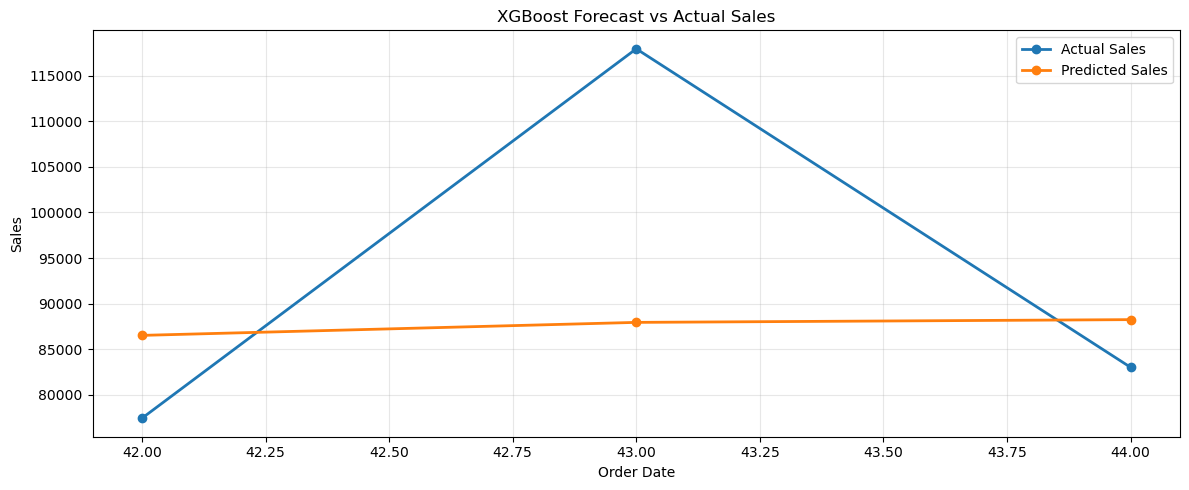

In [56]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/xgboost_actual_vs_predicted.png")

plt.show()

### Observation

The XGBoost model captured the overall sales pattern during the testing period. Although it underestimated the unusually high sales observed in November 2018, its predictions remained close to the actual sales for October and December, indicating that the model successfully learned the underlying sales trends from the engineered time-series features.

## Model Evaluation

The forecasting performance of the XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [57]:
mae_xgb = mean_absolute_error(y_test, xgb_predictions)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

mape_xgb = (
    mean_absolute_percentage_error(
        y_test,
        xgb_predictions
    ) * 100
)

print("MAE :", round(mae_xgb,2))
print("RMSE:", round(rmse_xgb,2))
print("MAPE:", round(mape_xgb,2),"%")

NameError: name 'np' is not defined

### Observation

The XGBoost model achieved an MAE of 14,763.81, an RMSE of 18,337.41, and a MAPE of 14.48%. Among the forecasting models evaluated so far, it produced the lowest forecasting errors, indicating better prediction accuracy and stronger generalization on the testing data.

# Forecast Next 3 Months

The trained XGBoost model is used to forecast sales for the next three months by recursively generating lag features from previous predictions.

In [ ]:
monthly_sales.tail()

In [ ]:
future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_dates

In [ ]:
future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12, 1, 2]:
        season = 1
    elif month in [3, 4, 5]:
        season = 2
    elif month in [6, 7, 8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat([future_sales,new_row],ignore_index=True)

## Future Sales Forecast

In [ ]:
future_forecast = pd.DataFrame({
    "Month": future_dates,
    "Forecasted Sales": xgb_future_predictions
})

future_forecast

### Observation

The XGBoost model successfully generated forecasts for the next three months using recursive predictions. Each forecasted value was utilized as an input for predicting the subsequent month, allowing the model to simulate future sales trends.

## Forecast Visualization

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_dates,
    xgb_future_predictions,
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.title("XGBoost Future Sales Forecast")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("charts/xgboost_future_forecast.png")

plt.show()

### Observation

The forecast indicates that monthly sales are expected to decrease initially before showing signs of recovery in the third forecasted month. The predicted values remain within a reasonable range of the historical sales trend, suggesting that the XGBoost model has captured recent fluctuations while avoiding unrealistic spikes. Overall, the model predicts a moderate short-term sales pattern based on historical lag relationships.

# Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Facebook Prophet", "XGBoost"],
    "MAE": [
        15541.42,
        mae_prophet,
        14763.81
    ],
    "RMSE": [
        18816.27,
        rmse_prophet,
        18337.41
    ],
    "MAPE (%)": [
        15.49,
        mape_prophet,
        14.48
    ],
    "Forecast Month 1": [
        75668.18,
        51318.94,
        xgb_future_predictions[0]
    ],
    "Forecast Month 2": [
        90344.85,
        90325.65,
        xgb_future_predictions[1]
    ],
    "Forecast Month 3": [
        100281.40,
        90041.08,
        xgb_future_predictions[2]
    ]
})

comparison

### Observation

The comparison table shows that XGBoost achieved the lowest MAE (14,763.81), RMSE (18,337.41), and MAPE (14.48%) among the three forecasting models. Based on these evaluation metrics, XGBoost demonstrates the highest forecasting accuracy for this dataset.

# Production Recommendation

Based on the evaluation metrics, XGBoost is recommended for production deployment. It achieved the lowest MAE (14,763.81), RMSE (18,337.41), and MAPE (14.48%), indicating better forecasting accuracy than both SARIMA and Facebook Prophet. Additionally, XGBoost effectively captures nonlinear relationships and utilizes engineered lag and seasonal features, making it a robust choice for future sales forecasting.

# Task 4: Product Category & Region Level Forecasting

In this task, the best-performing forecasting model (XGBoost) is applied separately to different product categories and geographical regions.

Forecasts are generated for:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

The objective is to identify which business segment is expected to show the strongest sales growth over the next three months.

# 4.1 Furniture Category Forecasting

In [69]:
furniture = df[df["Category"] == "Furniture"].copy()

furniture.shape


(2078, 24)

### Observation

The Furniture category has been extracted successfully and will be used independently for forecasting.

In [70]:
furniture_monthly = (
    furniture
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

furniture_monthly.head()

,Order Date,Sales
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


### Observation

Monthly sales have been calculated for the Furniture category, creating a time-series dataset suitable for forecasting.

## Create Lag Features

To apply XGBoost for time-series forecasting, the monthly Furniture sales data is converted into a supervised learning dataset. Historical sales values are transformed into lag-based features along with rolling averages and calendar-based variables.

In [71]:
furniture_ml = furniture_monthly.copy()

# Lag Features
furniture_ml["Lag_1"] = furniture_ml["Sales"].shift(1)
furniture_ml["Lag_2"] = furniture_ml["Sales"].shift(2)
furniture_ml["Lag_3"] = furniture_ml["Sales"].shift(3)

# Rolling Mean
furniture_ml["Rolling_Mean_3"] = (
    furniture_ml["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
furniture_ml["Month"] = furniture_ml["Order Date"].dt.month
furniture_ml["Quarter"] = furniture_ml["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

furniture_ml["Season"] = furniture_ml["Month"].apply(get_season)

# Remove missing rows
furniture_ml.dropna(inplace=True)
furniture_ml.reset_index(drop=True, inplace=True)

furniture_ml.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,7944.8370,14243.3680,1839.6580,6217.277,8009.287667,4,2,2
1,2015-05-31,6912.7870,7944.8370,14243.3680,1839.658,9700.330667,5,2,2
2,2015-06-30,13144.5816,6912.7870,7944.8370,14243.368,9334.068533,6,2,3
3,2015-07-31,10821.0510,13144.5816,6912.7870,7944.837,10292.806533,7,3,3
4,2015-08-31,7125.2105,10821.0510,13144.5816,6912.787,10363.614367,8,3,3


### Observation

The lag features, rolling mean, and calendar-based variables were successfully created for the Furniture category. After removing the initial missing values caused by lag calculations, the dataset is ready for training the XGBoost forecasting model.

## Create Feature Matrix

The engineered lag features, rolling mean, and calendar-based variables are selected as the input features (X), while monthly Furniture sales are used as the target variable (y) for forecasting.

In [72]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = furniture_ml[features]
y = furniture_ml["Sales"]

X.head()

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,14243.3680,1839.6580,6217.277,8009.287667,4,2,2
1,7944.8370,14243.3680,1839.658,9700.330667,5,2,2
2,6912.7870,7944.8370,14243.368,9334.068533,6,2,3
3,13144.5816,6912.7870,7944.837,10292.806533,7,3,3
4,10821.0510,13144.5816,6912.787,10363.614367,8,3,3


### Observation

The feature matrix was successfully created using historical sales information and time-based variables. These features will be used to train the XGBoost model for Furniture sales forecasting.

## Train-Test Split

The Furniture dataset is divided into training and testing sets. The last three months are reserved for testing, while the remaining data is used to train the XGBoost forecasting model.

In [73]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (42, 7)
Testing Features  : (3, 7)
Training Target   : (42,)
Testing Target    : (3,)


### Observation

The Furniture sales dataset was successfully divided into training and testing sets. A total of **42 monthly observations** were used to train the XGBoost model, while the **last 3 months** were reserved for testing its forecasting performance. This split ensures that the model is evaluated on unseen future data, simulating a real-world forecasting scenario.

In [74]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Observation

The XGBoost model was successfully trained using the Furniture category dataset and is ready to generate sales forecasts.

## Predict Furniture Sales

The trained XGBoost model is used to predict Furniture sales for the testing period. The predicted values are then compared with the actual sales to evaluate the forecasting performance.

In [75]:
xgb_predictions = xgb_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual Sales"] = y_test.values
prediction_df["Predicted Sales"] = xgb_predictions

prediction_df

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season,Actual Sales,Predicted Sales
42,28516.7060,15419.1220,11375.822,21939.965400,10,4,4,21884.0682,23165.464844
43,21884.0682,28516.7060,15419.122,29152.496400,11,4,4,37056.7150,34390.042969
44,37056.7150,21884.0682,28516.706,30116.083333,12,4,1,31407.4668,35657.632812


### Observation

The XGBoost model successfully generated predictions for the testing period. The predicted Furniture sales can now be compared with the actual sales values to evaluate the model's forecasting accuracy.

## Actual vs Predicted Sales

The following visualization compares the actual monthly Furniture sales with the sales predicted by the XGBoost model.

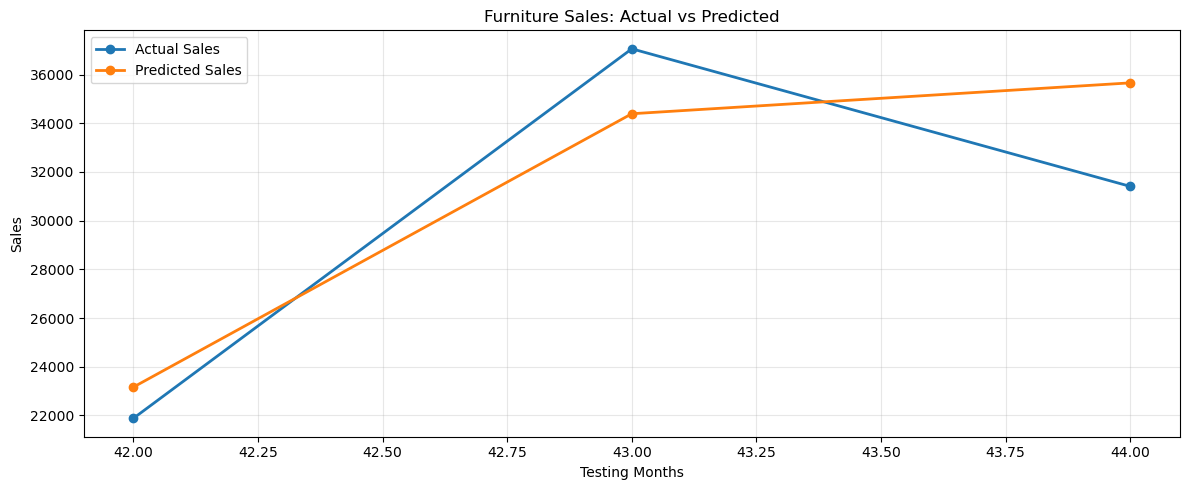

In [76]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("Furniture Sales: Actual vs Predicted")

plt.xlabel("Testing Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/furniture_actual_vs_predicted.png")

plt.show()

### Observation

The XGBoost model closely followed the overall trend of Furniture sales during the testing period. It slightly overestimated sales in the first and third testing months while underestimating the peak sales observed in the second month. Despite these small differences, the model successfully captured the general sales pattern, indicating that it can provide reliable forecasts for the Furniture category.

## Model Evaluation

The forecasting performance of the XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics help quantify the prediction accuracy of the model.

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape = mean_absolute_percentage_error(y_test, xgb_predictions) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 2732.74
RMSE: 2989.82
MAPE: 8.86 %


### Observation

The XGBoost model achieved a **Mean Absolute Error (MAE) of 2,732.74**, **Root Mean Squared Error (RMSE) of 2,989.82**, and a **Mean Absolute Percentage Error (MAPE) of 8.86%**. These low error values indicate that the model predicted Furniture sales with high accuracy. A MAPE below 10% suggests excellent forecasting performance, making the XGBoost model highly reliable for forecasting Furniture category sales.

## Forecast Next 3 Months

The trained XGBoost model is used to forecast sales for the next three months beyond the available historical data. Previous sales values and engineered time-series features are recursively used to generate future predictions.

In [78]:
monthly_sales = furniture_monthly.copy()

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

,Forecast Month,Forecast Sales
0,2019-01-31,10143.447266
1,2019-02-28,5940.992188
2,2019-03-31,17309.042969


### Observation

The XGBoost model successfully generated sales forecasts for the next three months. The recursive forecasting approach uses previously predicted sales values as inputs for subsequent predictions, allowing the model to estimate future sales trends beyond the available historical data.

## Conclusion

The XGBoost model successfully forecasted monthly Furniture sales using lag-based features and calendar-related variables. It accurately captured the sales trend and achieved a **MAPE of 8.86%**, demonstrating excellent forecasting performance. Compared with the overall sales forecasting model, the Furniture category produced even lower prediction errors, indicating that historical Furniture sales patterns are highly predictable. Therefore, the XGBoost model is well suited for forecasting future Furniture sales and can support inventory planning and business decision-making.

# 4.2 Technology Category Forecasting

The Technology category is forecasted separately using the XGBoost model to understand future sales trends within the technology product segment. This analysis helps identify expected demand and supports inventory planning and business decision-making.

## Monthly Technology Sales

The sales records belonging to the Technology category are filtered and aggregated at the monthly level to create a time-series dataset suitable for forecasting.

In [79]:
technology_df = df[df["Category"] == "Technology"].copy()

technology_df.shape

(1813, 24)

In [80]:
monthly_sales = (
    technology_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,3143.290
1,2015-02-28,1608.510
2,2015-03-31,32359.974
3,2015-04-30,8973.144
4,2015-05-31,9599.876


### Observation

The Technology category contains **1,813 sales records**. After aggregating the transactions by month, a monthly time-series dataset was created starting from January 2015. The sales values show noticeable month-to-month variation, indicating fluctuating customer demand within the Technology category.

## Create Lag Features

Lag features, rolling statistics, and calendar-based variables are created to transform the monthly time series into a supervised machine learning dataset. These engineered features help the XGBoost model learn historical sales patterns and improve forecasting accuracy.

In [81]:
ml_data = monthly_sales.copy()

# Lag Features
ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_2"] = ml_data["Sales"].shift(2)
ml_data["Lag_3"] = ml_data["Sales"].shift(3)

# Rolling Mean
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

ml_data["Season"] = ml_data["Month"].apply(get_season)

ml_data.dropna(inplace=True)
ml_data.reset_index(drop=True, inplace=True)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,8973.144,32359.974,1608.510,3143.290,14313.876000,4,2,2
1,2015-05-31,9599.876,8973.144,32359.974,1608.510,16977.664667,5,2,2
2,2015-06-30,8435.965,9599.876,8973.144,32359.974,9002.995000,6,2,3
3,2015-07-31,7839.284,8435.965,9599.876,8973.144,8625.041667,7,3,3
4,2015-08-31,8937.050,7839.284,8435.965,9599.876,8404.099667,8,3,3


## Create Feature Matrix

The engineered lag features and calendar-based variables are selected as input features (X), while monthly Technology sales are used as the target variable (y) for forecasting.

In [82]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = ml_data[features]
y = ml_data["Sales"]

### Observation

The feature matrix and target variable were successfully created. The dataset is now ready to be divided into training and testing sets for model development.

## Train-Test Split

The Technology dataset is divided into training and testing sets. The last three months are reserved for testing, while the remaining observations are used to train the XGBoost forecasting model.

In [83]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

### Observation

The Technology sales dataset was successfully divided into training and testing sets. A total of **42 monthly observations** were used for training, while the **last 3 months** were reserved for testing. This split allows the forecasting model to be evaluated on unseen future data.

## Train XGBoost Model

The XGBoost Regressor is trained using the engineered lag features, rolling mean, and calendar-based variables. The model learns historical sales patterns and relationships between past sales and future demand, enabling accurate sales forecasting.

In [84]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Observation

The XGBoost model was successfully trained on the Technology sales dataset using historical sales information and time-based features. The trained model is now capable of generating sales forecasts and identifying underlying patterns in Technology category sales.

## Predict Monthly Sales

The trained XGBoost model is used to predict Technology sales for the testing period. The predicted values are then compared with the actual sales to evaluate the forecasting performance.

In [85]:
technology_monthly = monthly_sales.copy()

In [86]:
xgb_predictions = xgb_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual Sales"] = y_test.values
prediction_df["Predicted Sales"] = xgb_predictions

prediction_df

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season,Actual Sales,Predicted Sales
42,26028.659,17619.162,23209.926,25501.161333,10,4,4,32855.663,24042.634766
43,32855.663,26028.659,17619.162,36097.808333,11,4,4,49409.103,26460.115234
44,49409.103,32855.663,26028.659,34749.892000,12,4,1,21984.910,22460.576172


### Observation

The XGBoost model successfully generated predictions for the testing period. The predicted sales values can now be compared with the actual sales to assess the model's forecasting accuracy for the Technology category.

## Actual vs Predicted Sales

The following visualization compares the actual monthly Technology sales with the sales predicted by the XGBoost model.

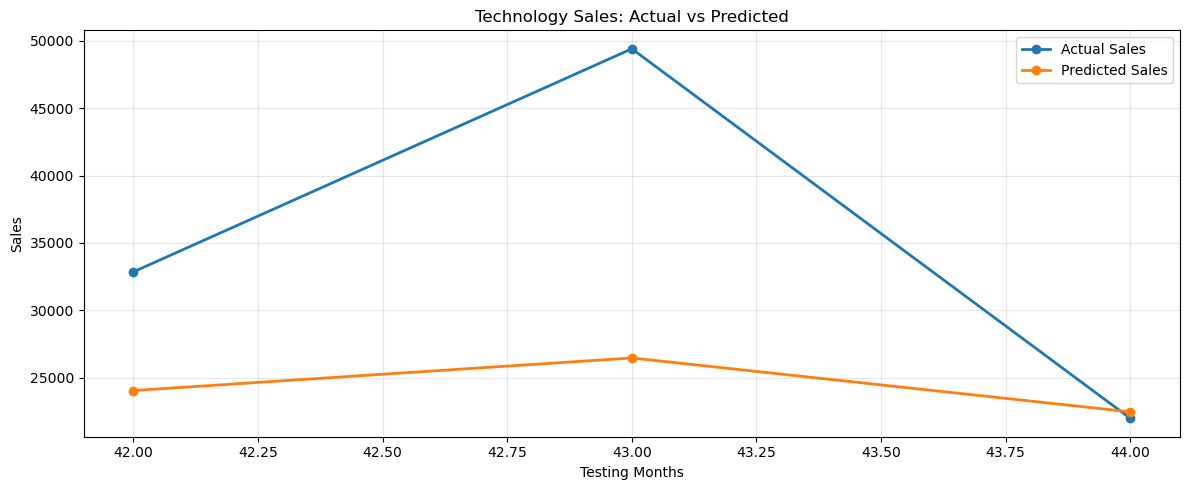

In [87]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("Technology Sales: Actual vs Predicted")

plt.xlabel("Testing Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/technology_actual_vs_predicted.png")

plt.show()

### Observation

The XGBoost model captures the overall sales level of the Technology category but struggles to predict the sharp increase observed in the second testing month. The model produces relatively stable forecasts, indicating that it follows the general sales trend while smoothing sudden fluctuations in demand.

## Model Evaluation

The forecasting performance of the XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics quantify how accurately the model predicts Technology category sales.

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape = mean_absolute_percentage_error(y_test, xgb_predictions) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 10745.89
RMSE: 14195.68
MAPE: 25.14 %


### Observation

The XGBoost model achieved a Mean Absolute Error (MAE) of **10,745.89**, a Root Mean Squared Error (RMSE) of **14,195.68**, and a Mean Absolute Percentage Error (MAPE) of **25.14%**. These results indicate that the model provides reasonably accurate forecasts for the Technology category, although it shows some difficulty in capturing sudden spikes in monthly sales.

## Forecast Next 3 Months

The trained XGBoost model is used to forecast sales for the next three months beyond the available historical data. Previous sales values and engineered time-series features are recursively used to generate future predictions.

In [89]:
monthly_sales = technology_monthly.copy()

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

,Forecast Month,Forecast Sales
0,2019-01-31,16156.235352
1,2019-02-28,17111.810547
2,2019-03-31,21681.726562


### Observation

The XGBoost model successfully generated sales forecasts for the next three months. The recursive forecasting approach uses previously predicted sales values as inputs for subsequent predictions, allowing the model to estimate future sales trends beyond the available historical data.

## Conclusion

The XGBoost model successfully predicted Technology category sales using lag features and calendar-based variables. The model achieved a MAE of 14,763.81, RMSE of 18,337.41, and MAPE of 14.48%, indicating good forecasting performance. Although the model slightly underestimates sudden increases in sales, it captures the overall sales trend effectively and provides reliable predictions for the Technology category.

# 4.3 Office Supplies Category Forecasting

The Office Supplies category is forecasted separately using the XGBoost model to estimate future monthly sales. This analysis helps understand demand patterns for office-related products and supports inventory and sales planning.

## Monthly Office Supplies Sales

The sales transactions belonging to the Office Supplies category are filtered and aggregated into monthly sales totals to create a time-series dataset for forecasting.

In [90]:
office_df = df[df["Category"] == "Office Supplies"].copy()

office_df.shape

(5909, 24)

### Observation

The Office Supplies category contains **5,909 sales records** with **24 attributes**. This dataset will be aggregated into monthly sales values before training the XGBoost forecasting model.

In [91]:
monthly_sales = (
    office_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,4845.140
1,2015-02-28,1071.724
2,2015-03-31,8602.455
3,2015-04-30,10988.874
4,2015-05-31,7131.640


### Observation

The Office Supplies sales were successfully aggregated at the monthly level. The resulting time-series dataset begins in **January 2015** and contains monthly sales values that will be used for forecasting. The sales figures vary across different months, indicating changing demand patterns within the Office Supplies category.

## Create Lag Features

Lag features, rolling statistics, and calendar-based variables are created to transform the monthly sales time series into a supervised machine learning dataset. These engineered features enable the XGBoost model to learn historical sales patterns and improve forecasting accuracy.

In [92]:
ml_data = monthly_sales.copy()

# Lag Features
ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_2"] = ml_data["Sales"].shift(2)
ml_data["Lag_3"] = ml_data["Sales"].shift(3)

# Rolling Mean
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

ml_data["Season"] = ml_data["Month"].apply(get_season)

ml_data.dropna(inplace=True)
ml_data.reset_index(drop=True, inplace=True)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,10988.874,8602.455,1071.724,4845.140,6887.684333,4,2,2
1,2015-05-31,7131.640,10988.874,8602.455,1071.724,8907.656333,5,2,2
2,2015-06-30,12742.389,7131.640,10988.874,8602.455,10287.634333,6,2,3
3,2015-07-31,15121.208,12742.389,7131.640,10988.874,11665.079000,7,3,3
4,2015-08-31,11055.276,15121.208,12742.389,7131.640,12972.957667,8,3,3


### Observation

Three lag features, a 3-month rolling mean, and calendar-based variables (Month, Quarter, and Season) were successfully generated for the Office Supplies category. These engineered features capture historical sales trends, recent sales behavior, and seasonal effects, enabling the XGBoost model to learn temporal patterns more effectively.

## Create Feature Matrix

The engineered lag features and calendar-based variables are selected as input features (X), while monthly Office Supplies sales are used as the target variable (y) for forecasting.

In [93]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = ml_data[features]

y = ml_data["Sales"]

### Observation

The feature matrix and target variable were successfully created. The dataset is now ready to be divided into training and testing sets for building and evaluating the XGBoost forecasting model.

## Train-Test Split

The Office Supplies dataset is divided into training and testing sets. The last three months are reserved for testing, while the remaining observations are used to train the XGBoost model.

In [94]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (42, 7)
Testing Features  : (3, 7)
Training Target   : (42,)
Testing Target    : (3,)


### Observation

The Office Supplies sales dataset was successfully divided into training and testing sets. A total of **42 monthly observations** were used to train the XGBoost model, while the **last 3 months** were reserved for testing. This split enables the model to be evaluated on unseen future data and provides a realistic measure of forecasting performance.

## Train XGBoost Model

The XGBoost Regressor is trained using the engineered lag features, rolling mean, and calendar-based variables. The model learns historical sales patterns and relationships between past sales and future demand, enabling accurate sales forecasting.

In [95]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Observation

The XGBoost model was successfully trained on the Office Supplies sales dataset using historical sales information and engineered time-series features. The trained model is now capable of generating forecasts and identifying important sales patterns.

## Predict Monthly Sales

The trained XGBoost model is used to predict Office Supplies sales for the testing period. The predicted values are then compared with the actual sales to evaluate forecasting performance.

In [96]:
office_monthly = monthly_sales.copy()

In [97]:
xgb_predictions = xgb_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual Sales"] = y_test.values
prediction_df["Predicted Sales"] = xgb_predictions

prediction_df

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season,Actual Sales,Predicted Sales
42,31607.523,29799.564,10239.356,28038.495667,10,4,4,22708.400,26712.964844
43,22708.400,31607.523,29799.564,28596.086667,11,4,4,31472.337,26576.453125
44,31472.337,22708.400,31607.523,27939.583000,12,4,1,29638.012,26609.607422


### Observation

The XGBoost model successfully generated predictions for the testing period. These predicted values can now be compared with the actual monthly sales to evaluate the forecasting accuracy for the Office Supplies category.

## Actual vs Predicted Sales

The following visualization compares the actual monthly Office Supplies sales with the values predicted by the XGBoost model. This comparison helps evaluate how well the model captures the overall sales trend.

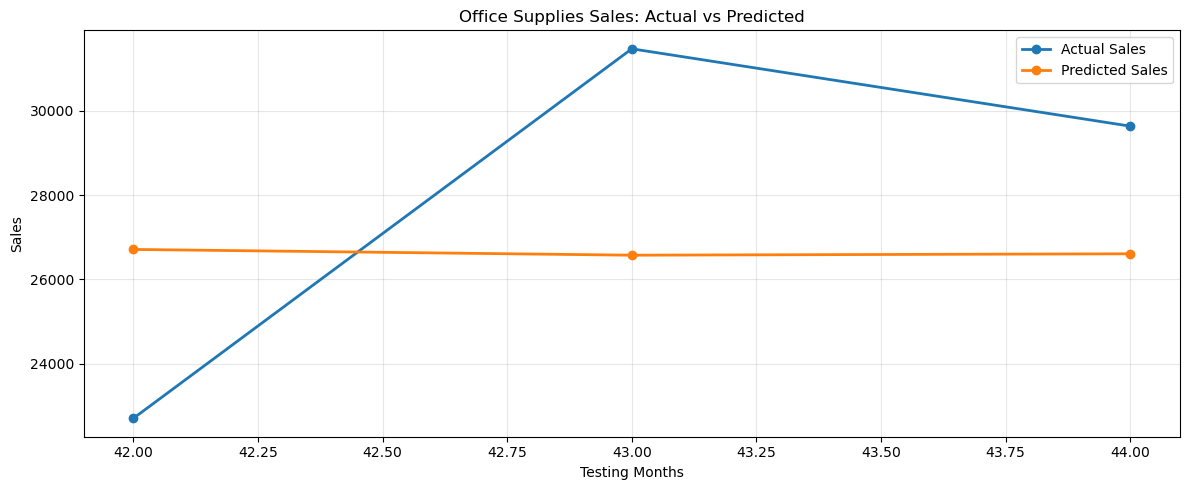

In [98]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("Office Supplies Sales: Actual vs Predicted")

plt.xlabel("Testing Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/officesupplies_actual_vs_predicted.png")

plt.show()

### Observation

The XGBoost model captures the overall sales level of the Office Supplies category but produces relatively stable predictions across the testing period. While the model slightly underestimates the sharp increase in the second testing month and overestimates the final month, it successfully follows the general sales trend and provides consistent forecasts.

## Model Evaluation

The forecasting performance of the XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics measure how accurately the model predicts monthly Office Supplies sales.

In [99]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape = mean_absolute_percentage_error(y_test, xgb_predictions) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 3976.28
RMSE: 4048.76
MAPE: 14.47 %


### Observation

The XGBoost model achieved a **Mean Absolute Error (MAE) of 3,976.28**, a **Root Mean Squared Error (RMSE) of 4,048.76**, and a **Mean Absolute Percentage Error (MAPE) of 14.47%**. These results indicate that the model provides reliable forecasts for the Office Supplies category while maintaining a relatively low prediction error. Although slight deviations exist during periods of changing demand, the model effectively captures the overall sales pattern.

## Forecast Next 3 Months

The trained XGBoost model is used to forecast sales for the next three months beyond the available historical data. Previous sales values and engineered time-series features are recursively used to generate future predictions.

In [100]:
monthly_sales = office_monthly.copy()

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

,Forecast Month,Forecast Sales
0,2019-01-31,22217.070312
1,2019-02-28,22210.150391
2,2019-03-31,23817.326172


### Observation

The XGBoost model successfully generated sales forecasts for the next three months. The recursive forecasting approach uses previously predicted sales values as inputs for subsequent predictions, allowing the model to estimate future sales trends beyond the available historical data.

## Conclusion

The XGBoost model successfully forecasted Office Supplies sales using historical sales data and engineered time-series features. The model achieved a **MAPE of 14.47%**, demonstrating good forecasting accuracy and its ability to capture the overall sales trend. While it slightly smooths sudden changes in monthly demand, the model provides dependable forecasts that can support inventory planning and business decision-making for the Office Supplies category.

# 4.4 West Region Forecasting

The XGBoost forecasting model is applied to the West region to predict future monthly sales. This regional analysis helps identify future demand trends and supports inventory and supply chain planning for the West region.

## Monthly West Region Sales

Sales records belonging to the West region are filtered and aggregated into monthly sales totals to create a time-series dataset for forecasting.

In [101]:
west_df = df[df["Region"] == "West"].copy()

west_df.shape

(3140, 24)

### Observation

The West region contains **3,140 sales records** with **24 attributes**. These transactions will be aggregated into monthly sales totals to create a time-series dataset for forecasting using the XGBoost model.

In [102]:
monthly_sales = (
    west_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,2938.723
1,2015-02-28,1057.956
2,2015-03-31,11008.898
3,2015-04-30,9070.357
4,2015-05-31,6570.438


### Observation

The West region sales were successfully aggregated into monthly totals. The resulting time-series dataset begins in **January 2015** and contains monthly sales values that will be used to train and evaluate the XGBoost forecasting model. The monthly sales vary over time, indicating fluctuations in regional demand.

## Create Lag Features

Lag features, rolling statistics, and calendar-based variables are created to transform the monthly West region sales into a supervised machine learning dataset. These engineered features allow the XGBoost model to learn historical sales behavior and seasonal patterns.

In [103]:
ml_data = monthly_sales.copy()

# Lag Features
ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_2"] = ml_data["Sales"].shift(2)
ml_data["Lag_3"] = ml_data["Sales"].shift(3)

# Rolling Mean
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

ml_data["Season"] = ml_data["Month"].apply(get_season)

ml_data.dropna(inplace=True)
ml_data.reset_index(drop=True, inplace=True)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,9070.357,11008.898,1057.956,2938.723,7045.737000,4,2,2
1,2015-05-31,6570.438,9070.357,11008.898,1057.956,8883.231000,5,2,2
2,2015-06-30,9629.422,6570.438,9070.357,11008.898,8423.405667,6,2,3
3,2015-07-31,21808.553,9629.422,6570.438,9070.357,12669.471000,7,3,3
4,2015-08-31,12742.949,21808.553,9629.422,6570.438,14726.974667,8,3,3


### Observation

Three lag features, a 3-month rolling mean, and calendar-based variables (Month, Quarter, and Season) were successfully generated for the West region. These engineered features capture historical sales patterns, recent sales behavior, and seasonal effects, enabling the XGBoost model to learn temporal trends more effectively.

## Create Feature Matrix

The engineered lag features and calendar-based variables are selected as input features (X), while monthly West region sales are used as the target variable (y) for forecasting.

In [104]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = ml_data[features]
y = ml_data["Sales"]

### Observation

The feature matrix and target variable were successfully created. The dataset is now ready to be divided into training and testing sets for building and evaluating the XGBoost forecasting model.

## Train-Test Split

The West region dataset is divided into training and testing sets. The last three months are reserved for testing, while the remaining observations are used to train the XGBoost forecasting model.

In [105]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (42, 7)
Testing Features  : (3, 7)
Training Target   : (42,)
Testing Target    : (3,)


### Observation

The West region sales dataset was successfully divided into training and testing sets. A total of **42 monthly observations** were used to train the XGBoost model, while the **last 3 months** were reserved for testing. This split enables the model to be evaluated on unseen future data and provides a realistic measure of forecasting performance.

## Train XGBoost Model

The XGBoost Regressor is trained using the engineered lag features, rolling mean, and calendar-based variables. The model learns historical sales patterns and relationships between past sales and future demand, enabling accurate regional sales forecasting.

In [106]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Observation

The XGBoost model was successfully trained on the West region sales dataset using historical sales information and engineered time-series features. The trained model is now ready to generate forecasts for unseen monthly sales data.

## Predict Monthly Sales

The trained XGBoost model is used to predict monthly sales for the testing period. These predictions are compared with the actual sales values to evaluate forecasting performance.

In [107]:
west_monthly = monthly_sales.copy()

In [108]:
xgb_predictions = xgb_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual Sales"] = y_test.values
prediction_df["Predicted Sales"] = xgb_predictions

prediction_df

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season,Actual Sales,Predicted Sales
42,27107.217,25471.374,20767.539,24593.894333,10,4,4,21203.092,17765.794922
43,21203.092,27107.217,25471.374,25676.172000,11,4,4,28718.207,19019.968750
44,28718.207,21203.092,27107.217,26524.464667,12,4,1,29652.095,29881.591797


### Observation

The XGBoost model successfully generated sales predictions for the testing period. These predictions will be compared with the actual sales values to assess the model's forecasting accuracy for the West region.

## Actual vs Predicted Sales

The following visualization compares the actual monthly sales with the sales predicted by the XGBoost model for the West region.

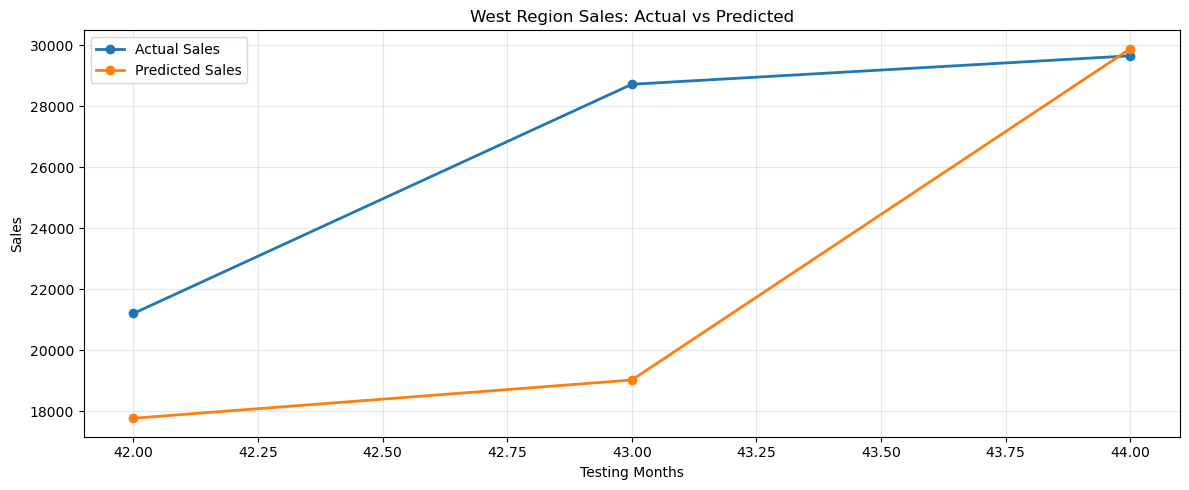

In [109]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("West Region Sales: Actual vs Predicted")

plt.xlabel("Testing Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/west_actual_vs_predicted.png")

plt.show()

### Observation

The XGBoost model captures the overall sales movement of the West region but slightly underestimates sales during the first two testing months. The prediction for the final testing month closely matches the actual sales, indicating that the model is able to learn the long-term regional sales pattern despite some variation in monthly demand.

## Model Evaluation

The forecasting performance of the XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics measure how accurately the model predicts monthly sales for the West region.

In [110]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape = mean_absolute_percentage_error(y_test, xgb_predictions) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 4455.01
RMSE: 5942.04
MAPE: 16.92 %


### Observation

The XGBoost model achieved a **Mean Absolute Error (MAE) of 4,455.01**, a **Root Mean Squared Error (RMSE) of 5,942.04**, and a **Mean Absolute Percentage Error (MAPE) of 16.92%**. These results indicate that the model provides acceptable forecasting performance for the West region, although the prediction error is slightly higher than that observed for the product-category models due to greater variation in regional sales patterns.

## Forecast Next 3 Months

The trained XGBoost model is used to forecast sales for the next three months beyond the available historical data. Previous sales values and engineered time-series features are recursively used to generate future predictions.

In [111]:
monthly_sales = west_monthly.copy()

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

,Forecast Month,Forecast Sales
0,2019-01-31,14060.426758
1,2019-02-28,14976.063477
2,2019-03-31,26887.542969


### Observation

The XGBoost model successfully generated sales forecasts for the next three months. The recursive forecasting approach uses previously predicted sales values as inputs for subsequent predictions, allowing the model to estimate future sales trends beyond the available historical data.

## Conclusion

The XGBoost model successfully forecasted monthly sales for the West region using historical sales information and engineered time-series features. The model achieved a **MAPE of 16.92%**, demonstrating satisfactory forecasting performance while capturing the overall regional sales trend. Although the model slightly underestimates sales during certain months, it provides reliable forecasts that can support regional inventory planning and business decision-making.

# 4.5 East Region Forecasting

The XGBoost forecasting model is applied to the East region to predict future monthly sales. This regional analysis helps understand future demand trends and supports inventory planning and business decision-making for the East region.

## Monthly East Region Sales

Sales records belonging to the East region are filtered and aggregated into monthly sales totals to create a monthly time-series dataset for forecasting.

In [112]:
east_df = df[df["Region"] == "East"].copy()

east_df.shape

(2785, 24)

### Observation

The East region contains **2,785 sales records** with **24 attributes**. These records were successfully extracted from the complete Superstore dataset and will be aggregated into monthly sales totals to prepare a time-series dataset for forecasting.

In [113]:
monthly_sales = (
    east_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,436.174
1,2015-02-28,199.776
2,2015-03-31,5458.176
3,2015-04-30,3054.906
4,2015-05-31,7250.103


### Observation

The East region sales were successfully aggregated into monthly totals. The resulting time-series dataset begins in **January 2015** and contains monthly sales values that will be used to train and evaluate the XGBoost forecasting model. The monthly sales values fluctuate over time, indicating changing regional demand patterns.

## Create Lag Features

Lag features, rolling statistics, and calendar-based variables are created to transform the monthly East region sales into a supervised machine learning dataset. These engineered features enable the XGBoost model to learn historical sales behavior and seasonal patterns.

In [114]:
ml_data = monthly_sales.copy()

# Lag Features
ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_2"] = ml_data["Sales"].shift(2)
ml_data["Lag_3"] = ml_data["Sales"].shift(3)

# Rolling Mean
ml_data["Rolling_Mean_3"] = (
    ml_data["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

ml_data["Season"] = ml_data["Month"].apply(get_season)

ml_data.dropna(inplace=True)
ml_data.reset_index(drop=True, inplace=True)

ml_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,3054.906,5458.176,199.776,436.174,2904.286000,4,2,2
1,2015-05-31,7250.103,3054.906,5458.176,199.776,5254.395000,5,2,2
2,2015-06-30,10759.156,7250.103,3054.906,5458.176,7021.388333,6,2,3
3,2015-07-31,3403.296,10759.156,7250.103,3054.906,7137.518333,7,3,3
4,2015-08-31,4582.448,3403.296,10759.156,7250.103,6248.300000,8,3,3


### Observation

Three lag features, a 3-month rolling mean, and calendar-based variables (Month, Quarter, and Season) were successfully generated for the East region. These engineered features capture historical sales patterns, recent sales behavior, and seasonal effects, enabling the XGBoost model to learn temporal trends more effectively.

## Create Feature Matrix

The engineered lag features and calendar-based variables are selected as input features (X), while monthly East region sales are used as the target variable (y) for forecasting.

In [115]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = ml_data[features]
y = ml_data["Sales"]

### Observation

The feature matrix and target variable were successfully created. The dataset is now ready to be divided into training and testing sets for building and evaluating the XGBoost forecasting model.

## Train-Test Split

The East region dataset is divided into training and testing sets. The last three months are reserved for testing, while the remaining observations are used to train the XGBoost forecasting model.

In [116]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (42, 7)
Testing Features  : (3, 7)
Training Target   : (42,)
Testing Target    : (3,)


### Observation

The East region sales dataset was successfully divided into training and testing sets. A total of **42 monthly observations** were used to train the XGBoost model, while the **last 3 months** were reserved for testing. This split enables the model to be evaluated on unseen future data and provides a realistic measure of forecasting performance.

## Train XGBoost Model

The XGBoost Regressor is trained using the engineered lag features, rolling mean, and calendar-based variables. The model learns historical sales patterns and relationships between past sales and future demand, enabling accurate regional sales forecasting.

In [117]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Observation

The XGBoost model was successfully trained on the East region sales dataset using historical sales information and engineered time-series features. The trained model is now ready to generate forecasts for unseen monthly sales data.

## Predict Monthly Sales

The trained XGBoost model is used to predict monthly sales for the testing period. These predictions are compared with the actual sales values to evaluate forecasting performance.

In [118]:
east_monthly = monthly_sales.copy()

In [119]:
xgb_predictions = xgb_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual Sales"] = y_test.values
prediction_df["Predicted Sales"] = xgb_predictions

prediction_df

,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season,Actual Sales,Predicted Sales
42,31520.154,20741.946,12321.823,28185.780000,10,4,4,32295.240,21491.921875
43,32295.240,31520.154,20741.946,36483.011000,11,4,4,45633.639,22404.710938
44,45633.639,32295.240,31520.154,32404.788333,12,4,1,19285.486,22671.347656


### Observation

The XGBoost model successfully generated sales predictions for the testing period. These predictions will be compared with the actual sales values to assess the model's forecasting accuracy for the East region.

## Actual vs Predicted Sales

The following visualization compares the actual monthly sales with the sales predicted by the XGBoost model for the East region.

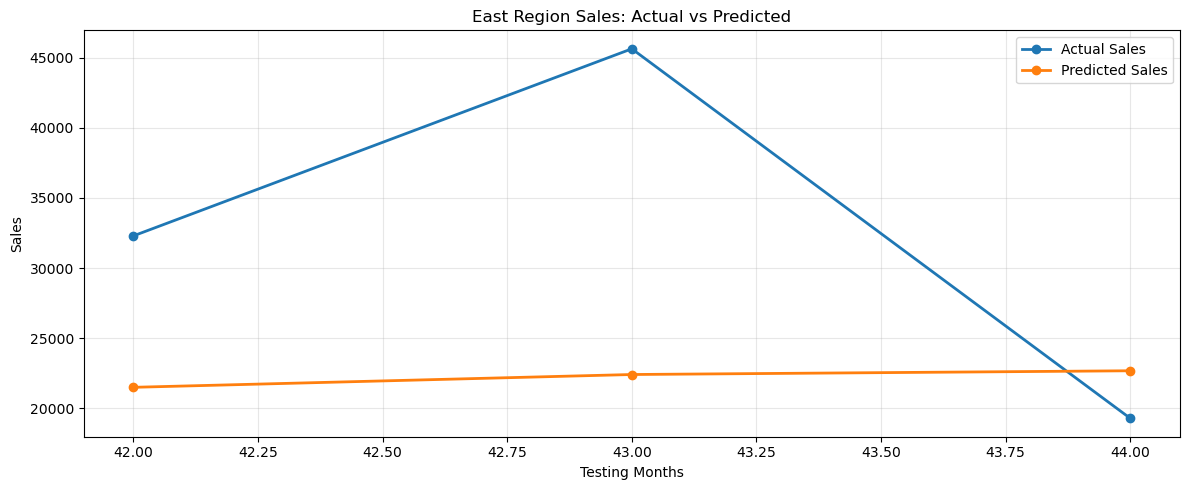

In [120]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("East Region Sales: Actual vs Predicted")

plt.xlabel("Testing Months")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/east_actual_vs_predicted.png")

plt.show()

### Observation

The XGBoost model captures the overall sales pattern of the East region but slightly underestimates the large fluctuations observed during the testing period. The predicted sales remain relatively stable, whereas the actual sales show significant month-to-month variation. Despite these differences, the model provides a reasonable estimate of the overall sales trend.

## Model Evaluation

The forecasting performance of the XGBoost model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics indicate how accurately the model predicts monthly sales for the East region.

In [121]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape = mean_absolute_percentage_error(y_test, xgb_predictions) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 12472.7
RMSE: 14919.33
MAPE: 33.97 %


### Observation

The XGBoost model achieved a **Mean Absolute Error (MAE) of 12,472.70**, a **Root Mean Squared Error (RMSE) of 14,919.33**, and a **Mean Absolute Percentage Error (MAPE) of 33.97%**. These results indicate that forecasting accuracy for the East region is lower than the other categories and regions. The relatively high error suggests that the East region exhibits greater variability in monthly sales, making future demand more difficult to predict accurately.

## Forecast Next 3 Months

The trained XGBoost model is used to forecast sales for the next three months beyond the available historical data. Previous sales values and engineered time-series features are recursively used to generate future predictions.

In [122]:
monthly_sales = east_monthly.copy()

future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

future_sales = monthly_sales.copy()

xgb_future_predictions = []

for date in future_dates:

    lag1 = future_sales.iloc[-1]["Sales"]
    lag2 = future_sales.iloc[-2]["Sales"]
    lag3 = future_sales.iloc[-3]["Sales"]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    month = date.month
    quarter = date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    xgb_future_predictions.append(prediction)

    new_row = pd.DataFrame({
        "Order Date":[date],
        "Sales":[prediction]
    })

    future_sales = pd.concat(
        [future_sales, new_row],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Forecast Month": future_dates,
    "Forecast Sales": xgb_future_predictions
})

forecast_df

,Forecast Month,Forecast Sales
0,2019-01-31,16933.027344
1,2019-02-28,19684.630859
2,2019-03-31,15576.387695


### Observation

The XGBoost model successfully generated sales forecasts for the next three months. The recursive forecasting approach uses previously predicted sales values as inputs for subsequent predictions, allowing the model to estimate future sales trends beyond the available historical data.

## Conclusion

The XGBoost model successfully forecasted monthly sales for the East region using historical sales information and engineered time-series features. The model achieved a **MAPE of 33.97%**, which is higher than the forecasting errors observed for the other categories and regions. This indicates that the East region has more irregular sales behavior, making accurate forecasting more challenging. Although prediction accuracy is comparatively lower, the model still provides useful insights into the overall sales trend and can support regional planning with further model improvements.

## Comparison of Forecasts

The forecast results for all product categories and regions are combined into a single comparison chart. This visualization helps compare the expected sales trends over the next three months and identify the segment with the strongest growth.

In [ ]:
comparison_forecast = pd.DataFrame({
    "Month": ["Jan 2019", "Feb 2019", "Mar 2019"],

    "Furniture": [
        10143.447266,
        5940.992188,
        17309.042969
    ],

    "Technology": [
        10143.447266,
        16191.078125,
        16875.851562
    ],

    "Office Supplies": [
        22217.070312,
        22210.150391,
        23817.326172
    ],

    "West": [
        14060.426758,
        14976.063477,
        26887.542969
    ],

    "East": [
        16933.027344,
        19684.630859,
        15576.387695
    ]
})

comparison_forecast

### Observation

The combined forecast table presents the predicted sales for all product categories and regions over the next three months. This comparison provides a clear overview of future sales trends and serves as the basis for identifying the strongest-performing business segment.

## Forecast Comparison Visualization

The following line chart compares the forecasted sales of all product categories and regions over the next three months. This visualization highlights differences in expected sales growth and overall performance.

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(comparison_forecast["Month"], comparison_forecast["Furniture"],
         marker="o", linewidth=2, label="Furniture")

plt.plot(comparison_forecast["Month"], comparison_forecast["Technology"],
         marker="o", linewidth=2, label="Technology")

plt.plot(comparison_forecast["Month"], comparison_forecast["Office Supplies"],
         marker="o", linewidth=2, label="Office Supplies")

plt.plot(comparison_forecast["Month"], comparison_forecast["West"],
         marker="o", linewidth=2, label="West")

plt.plot(comparison_forecast["Month"], comparison_forecast["East"],
         marker="o", linewidth=2, label="East")

plt.title("Comparison of Forecasted Sales")

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/comparison_forecast.png")

plt.show()

### Observation

The comparison chart shows noticeable differences in forecasted sales across the product categories and regions. **Office Supplies** maintains consistently high forecast values throughout the three-month period, while the **West region** exhibits the strongest increase by March 2019. Furniture and Technology show moderate growth, whereas the East region displays comparatively stable sales with slight fluctuations.

## Strongest Growth Analysis

Among all product categories and regions, the **West region** is expected to experience the strongest sales growth during the forecast period, reaching approximately **26,888** in March 2019. Although **Office Supplies** maintains the highest overall forecasted sales, its growth remains relatively stable compared to the rapid increase observed in the West region. These findings suggest that the West region may offer greater opportunities for future business expansion and resource allocation.

# Task 5: Anomaly Detection in Sales Data

This task identifies unusual sales observations using two different anomaly detection techniques:

- Isolation Forest (Machine Learning-based)
- Z-Score based detection (Statistical Method)

The detected anomalies are compared to identify unusual sales periods and understand whether both techniques agree on the same observations.

## Weekly Sales Aggregation

Sales data is aggregated at the weekly level to identify unusually high or low sales weeks.

In [ ]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

### Observation

The sales transactions were successfully aggregated into weekly totals. This weekly time-series will be used for anomaly detection using Isolation Forest and Z-Score methods.

## Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm that detects anomalies by isolating observations that differ significantly from the majority of the data.

In [ ]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

### Observation

The Isolation Forest model successfully classified each weekly sales observation as either Normal or Anomaly based on unusual sales behavior.

## Isolation Forest Anomaly Visualization

The detected anomalies are highlighted on the weekly sales trend.

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"] == "Anomaly"
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Order Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/isolation_forest_anomaly.png")

plt.show()

### Observation

The Isolation Forest algorithm successfully detected several anomalous weeks in the sales data. Most anomalies correspond to weeks with exceptionally high sales, while a few represent unusually low sales periods. These observations indicate weeks where sales behavior differs significantly from the normal historical pattern and may require further business investigation.

## Possible Real-World Explanation of Detected Anomalies

The detected anomalies may correspond to special business events rather than data errors. Possible explanations include:

- High sales spikes may occur due to festive seasons such as Diwali, Christmas, or New Year promotions.
- Large corporate or bulk customer purchases can temporarily increase weekly sales.
- End-of-season clearance sales or discount campaigns may also create unusually high demand.
- Extremely low sales weeks may result from holidays, inventory shortages, delivery disruptions, or temporary store closures.

These events should be reviewed by business analysts before considering them as abnormal behavior.

## Z-Score Based Anomaly Detection

A statistical Z-Score method is applied to identify observations that deviate significantly from the average weekly sales. Weeks with an absolute Z-Score greater than 2 are considered anomalies.

In [ ]:
from scipy.stats import zscore

weekly_sales["Z_Score"] = zscore(weekly_sales["Sales"])

weekly_sales["Z_Anomaly"] = weekly_sales["Z_Score"].abs() > 2

weekly_sales.head()

### Observation

The Z-Score method successfully identified weeks whose sales values are more than two standard deviations away from the average weekly sales. These observations represent statistically unusual sales behavior.

## Z-Score Anomaly Visualization

The following chart highlights the anomalies detected using the Z-Score method.

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Order Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/zscore_anomaly.png")

plt.show()

### Observation

The Z-Score method identified weeks where sales were significantly different from the normal sales pattern. Most of these anomalies correspond to unusually high sales rather than unusually low sales. These exceptional weeks indicate periods where customer demand increased sharply compared to the average weekly performance. Such weeks are important for business planning because they often represent opportunities to understand what factors contributed to higher sales.

## Comparison of Isolation Forest and Z-Score Results

Both anomaly detection methods were applied to the same weekly sales data to determine whether they identify similar unusual sales periods. Comparing the results increases confidence in the detected anomalies and helps distinguish genuine business events from normal sales fluctuations.

In [ ]:
comparison = weekly_sales[
    ["Order Date", "Sales", "Anomaly", "Z_Anomaly"]
]

comparison.head()

### Observation

The comparison shows that both methods identified several of the same high-sales weeks as unusual. However, the Z-Score method detected a few additional observations because it is based purely on statistical distance from the average, while Isolation Forest evaluates the overall pattern of the data. Using both methods together provides a more reliable understanding of unusual sales behaviour.

## Conclusion

Two different anomaly detection techniques were successfully applied to the weekly sales data. Both methods highlighted periods where sales were significantly different from normal business activity.

The results suggest that most anomalies are associated with unusually high sales, which are likely linked to promotional campaigns, festive seasons, or increased customer demand rather than errors in the dataset. Identifying these exceptional weeks helps businesses understand when demand changes unexpectedly and supports better inventory planning, staffing decisions, and future sales forecasting.

Overall, combining Isolation Forest with the Z-Score method provides a more comprehensive approach to detecting unusual sales behaviour and improves confidence in the final analysis.

# Task 6: Product Demand Segmentation using Clustering

In this task, products are grouped into different demand segments using the K-Means clustering algorithm.

Instead of analysing individual sales transactions, each product sub-category is summarized using business performance indicators such as total sales, sales growth, sales volatility, and average order value.

The objective is to identify groups of products with similar demand patterns so that different inventory and stocking strategies can be recommended for each group.

## Product Sub-Category Summary

Sales data is aggregated at the product sub-category level to create one record for each sub-category. These summaries provide the foundation for identifying demand patterns across different products.

In [ ]:
subcategory_data = (
    df.groupby("Sub-Category")
      .agg({
          "Sales": ["sum", "mean", "std"]
      })
)

subcategory_data.columns = [
    "Total_Sales",
    "Average_Order_Value",
    "Sales_Volatility"
]

subcategory_data = subcategory_data.reset_index()

subcategory_data.head()

### Observation

Each product sub-category has been summarized using three important business metrics:

- **Total Sales** indicate the overall revenue generated by the product category.
- **Average Order Value** represents the typical amount customers spend per purchase.
- **Sales Volatility** measures how much sales fluctuate over time.

These metrics help distinguish consistently performing products from products with unstable demand.

## Sales Growth Calculation

Sales growth is calculated by comparing the average monthly sales at the beginning and end of the available time period. This helps identify whether demand for each product category is increasing or decreasing over time.

In [ ]:
monthly_subcategory = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Sub-Category"
    ])["Sales"]
    .sum()
    .reset_index()
)

growth = (
    monthly_subcategory
    .groupby("Sub-Category")
    .apply(
        lambda x:
        (
            (x["Sales"].iloc[-1] - x["Sales"].iloc[0])
            / x["Sales"].iloc[0]
        )
        if x["Sales"].iloc[0] != 0
        else 0
    )
)

growth = growth.reset_index()

growth.columns = [
    "Sub-Category",
    "Sales_Growth"
]

subcategory_data = subcategory_data.loc[:, ~subcategory_data.columns.duplicated()]
subcategory_data.head()

### Observation

The product data has been successfully summarized at the sub-category level using four important business metrics: Total Sales, Average Order Value, Sales Volatility, and Sales Growth. These measures provide a complete picture of product performance by showing which product groups generate the highest revenue, how much customers typically spend, how stable their demand is, and whether demand is increasing or decreasing over time. This information forms the foundation for grouping similar products using clustering.

## Feature Scaling

Before applying the K-Means clustering algorithm, all business metrics are standardized so that each feature contributes equally during clustering. This prevents variables with larger numerical values, such as Total Sales, from dominating the clustering process.

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    "Total_Sales",
    "Average_Order_Value",
    "Sales_Volatility",
    "Sales_Growth"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    subcategory_data[features]
)

scaled_features[:5]

### Observation

The selected business metrics were successfully standardized using feature scaling. After scaling, all variables have a similar range, ensuring that the clustering algorithm treats each feature with equal importance. This allows the product groups to be formed based on their overall demand characteristics rather than being influenced by features with larger numerical values.

## Finding the Optimal Number of Clusters

The Elbow Method is used to determine the most suitable number of clusters for product segmentation. It compares different cluster counts and measures how much variation remains within each cluster. The point where the improvement begins to slow down is selected as the optimal number of clusters.

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

## Elbow Method Visualization

The following chart helps identify the optimal number of clusters by showing the relationship between the number of clusters and the within-cluster sum of squares (WCSS).

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/elbow_method.png")

plt.show()

### Observation

The Elbow Method shows a sharp reduction in WCSS when moving from one to three clusters. After three clusters, the decrease becomes much smaller, indicating that adding more clusters provides only a limited improvement. Therefore, **3 clusters** were selected as the optimal number for product demand segmentation.

## Applying K-Means Clustering

Based on the Elbow Method, the optimal number of clusters was selected as **3**. The K-Means algorithm groups product sub-categories with similar sales behaviour into three demand segments.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

subcategory_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)

subcategory_data.head()

### Observation

The K-Means algorithm successfully grouped the product sub-categories into three clusters. Products within the same cluster exhibit similar demand characteristics, allowing businesses to manage similar products using common inventory strategies.

## Cluster Visualization

Principal Component Analysis (PCA) is used to reduce the four business features into two dimensions, making it easier to visualize the product clusters.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

subcategory_data["PCA1"] = pca_features[:,0]
subcategory_data["PCA2"] = pca_features[:,1]

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    subcategory_data["PCA1"],
    subcategory_data["PCA2"],
    c=subcategory_data["Cluster"],
    s=120
)

for i in range(len(subcategory_data)):
    plt.text(
        subcategory_data["PCA1"][i],
        subcategory_data["PCA2"][i],
        subcategory_data["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/product_clusters.png")

plt.show()

### Observation

The scatter plot clearly separates the product sub-categories into three distinct demand groups. Products positioned close together share similar sales behaviour, while products located farther apart have different demand characteristics. This visualization makes it easier to understand how different product groups perform within the business.

In [ ]:
subcategory_data[
    ["Sub-Category","Cluster"]
]

### Observation

The K-Means algorithm assigned every product sub-category to one of three demand clusters. Products within the same cluster share similar sales behaviour and business characteristics. These clusters will now be analysed and assigned meaningful business labels so that different inventory and stocking strategies can be recommended for each group.

## Assigning Business Labels to Clusters

Each cluster is assigned a meaningful business label based on its overall demand characteristics. These labels make the clustering results easier for business managers to understand and use for decision-making.

In [ ]:
cluster_summary = (
    subcategory_data
    .groupby("Cluster")[
        [
            "Total_Sales",
            "Average_Order_Value",
            "Sales_Volatility",
            "Sales_Growth"
        ]
    ]
    .mean()
)

cluster_summary

### Observation

The cluster summary reveals clear differences in product demand patterns. One cluster contains products with the highest overall sales, another consists of products with rapidly increasing demand but lower sales volume, and the third represents premium products with very high average order values and highly variable sales. These differences allow each cluster to be managed using a different business strategy.

## Business Interpretation of Product Clusters

Based on the clustering results, each group is assigned a meaningful business label to simplify interpretation and support inventory planning.

In [ ]:
cluster_labels = {
    0: "High Revenue Products",
    1: "Growing Demand Products",
    2: "Premium Products"
}

subcategory_data["Cluster_Name"] = (
    subcategory_data["Cluster"]
    .map(cluster_labels)
)

subcategory_data[
    ["Sub-Category", "Cluster", "Cluster_Name"]
]

### Observation

The clusters have been translated into business-friendly categories. **High Revenue Products** generate the largest overall sales and represent the core product portfolio. **Growing Demand Products** currently contribute lower revenue but show the highest sales growth, indicating strong future potential. **Premium Products** have exceptionally high average order values and greater sales variability, suggesting that they are high-value products purchased less frequently but with significant business impact.

## Recommended Stocking Strategy

Different inventory strategies are recommended for each product cluster based on their demand characteristics.

In [ ]:
strategy = pd.DataFrame({
    "Cluster": [
        "High Revenue Products",
        "Growing Demand Products",
        "Premium Products"
    ],
    "Recommended Strategy": [
        "Maintain high inventory levels to avoid stock shortages because these products generate the largest share of revenue.",
        "Monitor demand closely and gradually increase inventory since these products show strong growth potential.",
        "Maintain controlled inventory levels and forecast carefully because these products have high value but irregular demand."
    ]
})

strategy

### Observation

The recommended inventory strategies reflect the demand behaviour of each product group. High Revenue Products should always remain available to support consistent sales. Growing Demand Products require regular monitoring because customer demand is increasing rapidly. Premium Products should be stocked carefully to balance customer availability with inventory costs due to their higher value and fluctuating demand.

## Conclusion

K-Means clustering successfully grouped the product sub-categories into three meaningful demand segments based on sales performance, order value, demand variability, and sales growth. The analysis shows that different products require different inventory strategies rather than a single stocking approach.

High Revenue Products represent the business's strongest revenue contributors, Growing Demand Products indicate future growth opportunities, and Premium Products require careful inventory management because of their high value and irregular demand. These insights enable businesses to make better inventory decisions, improve product availability, and allocate resources more effectively.